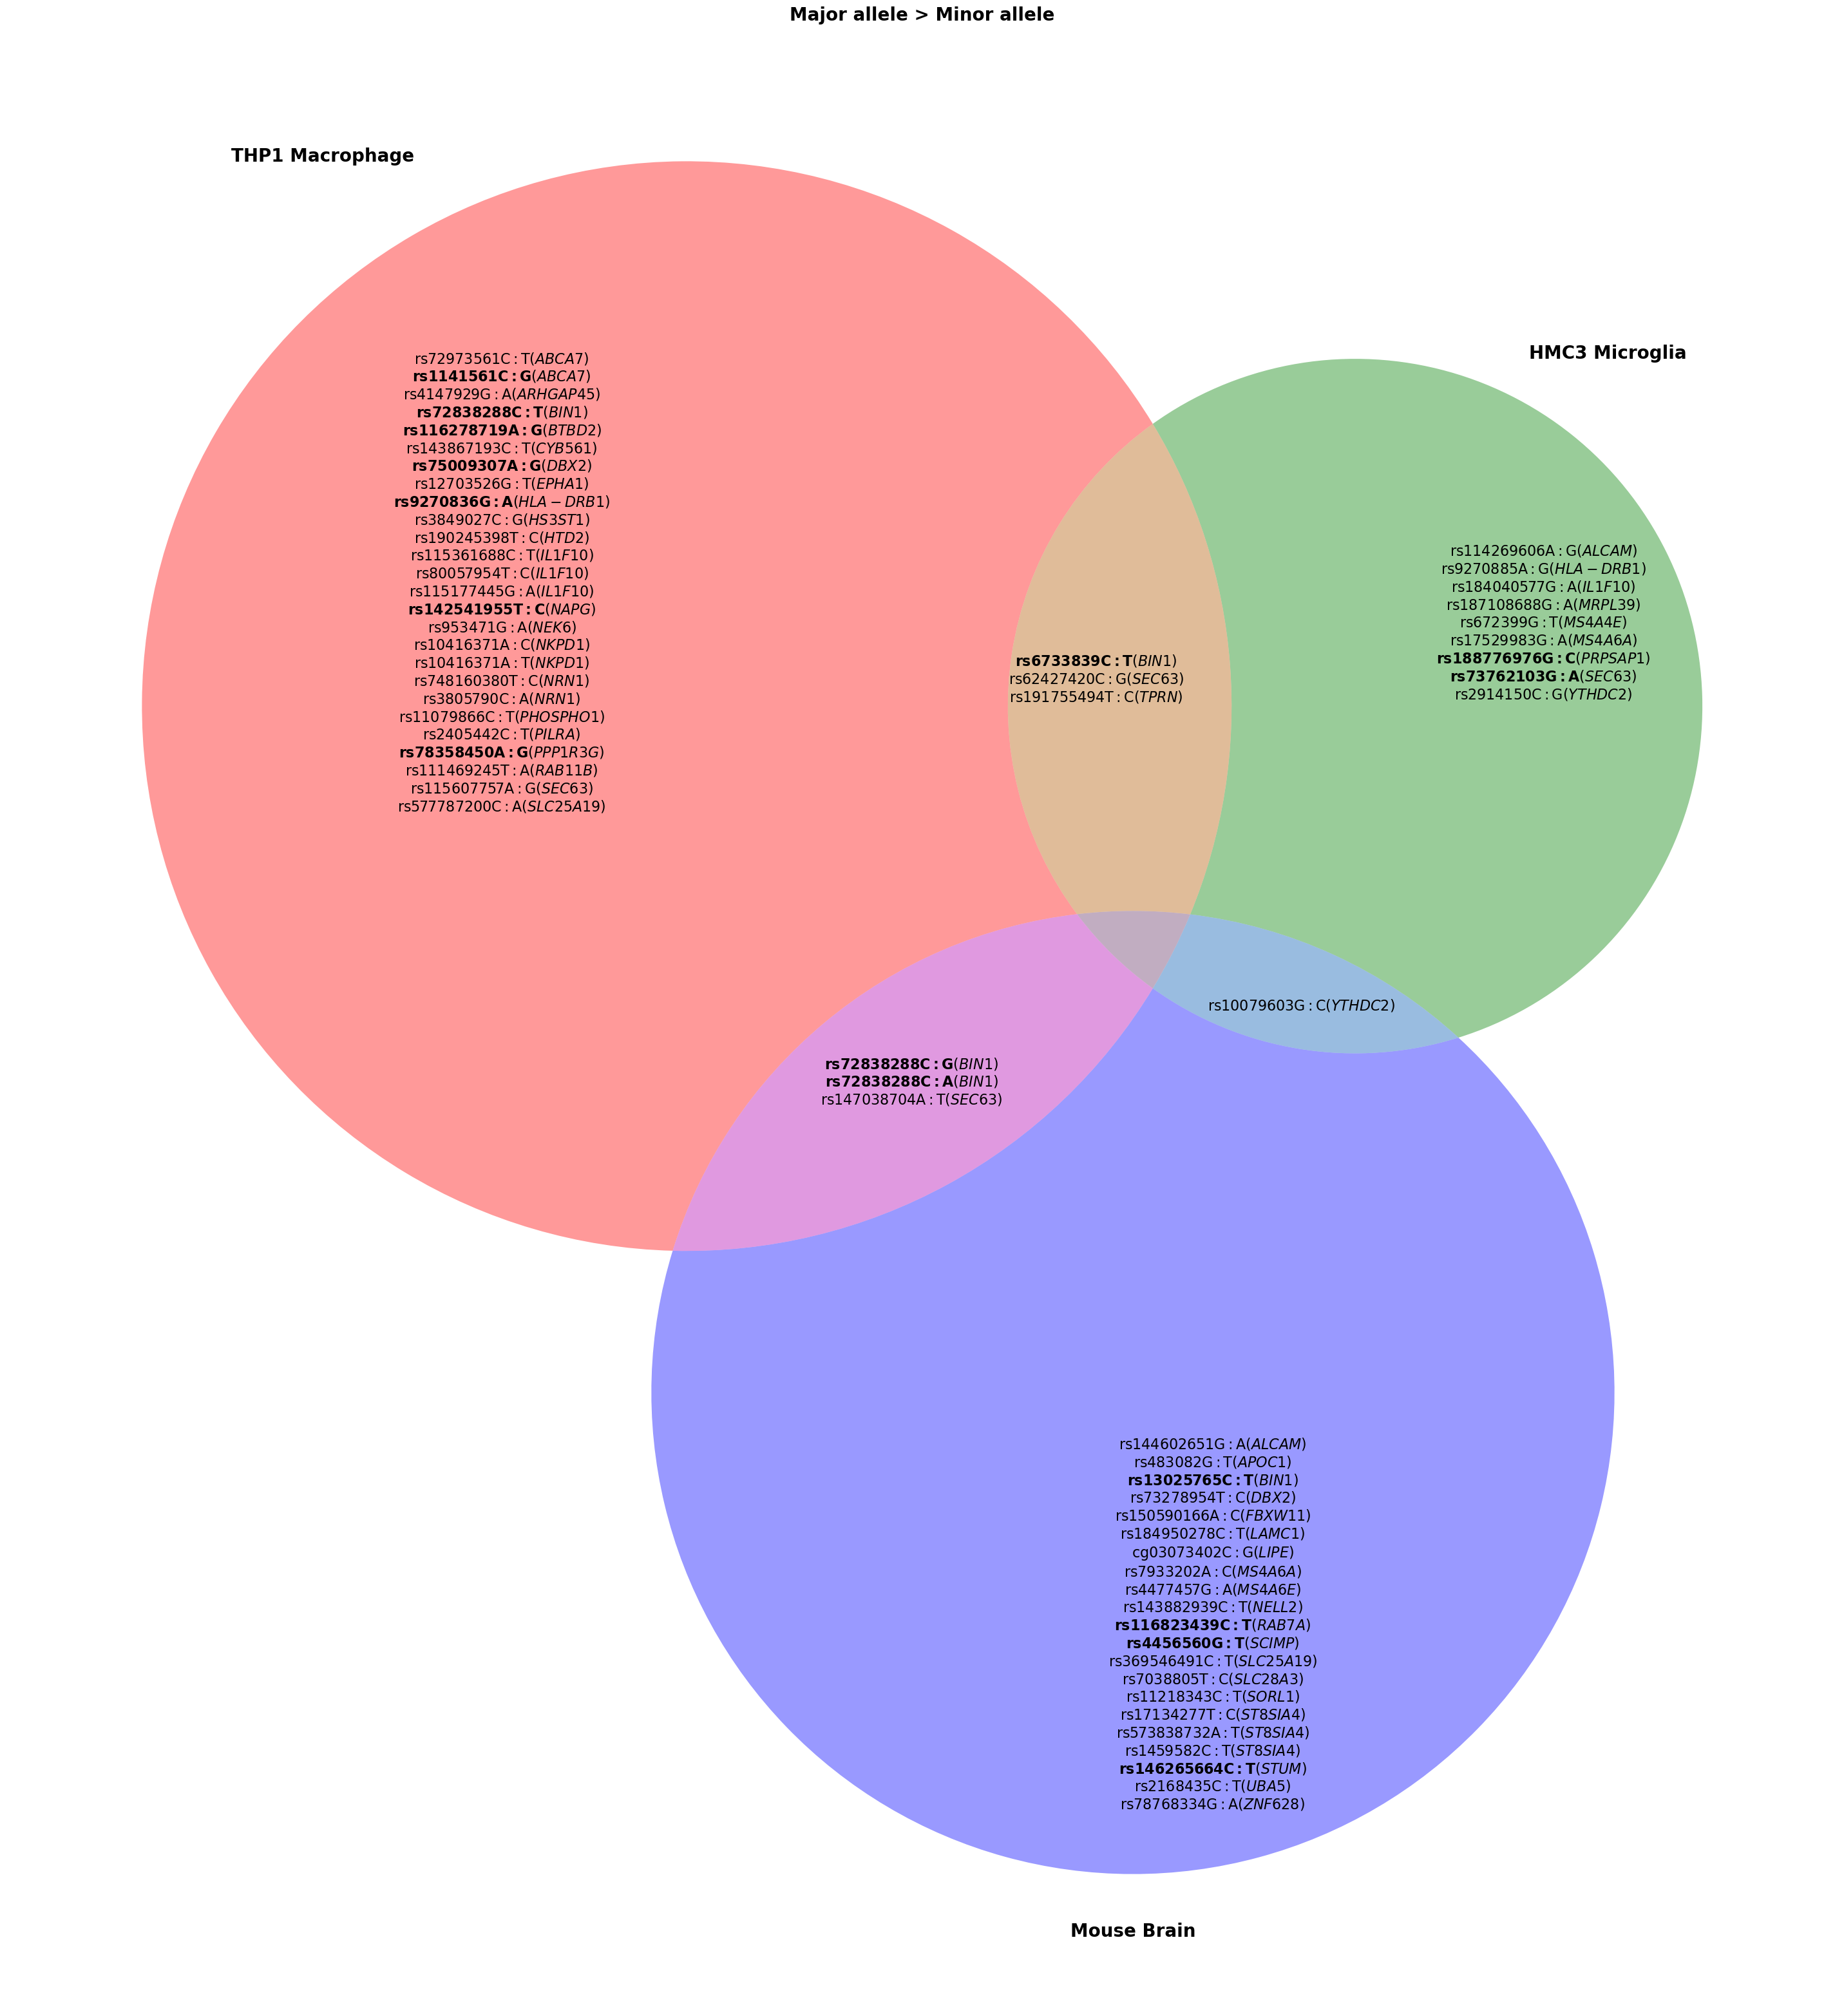

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
df_ml = pd.read_csv("indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_20250608.csv",index_col=0)
#df_ml_sig_brain = df_ml[[       'ML_majorminor_logFC_genomic_Mouse_Cortex_AgeB-model',
#       'ML_majorminor_logFC_genomic_Mouse_Cortex_AgeC-model',
#       'ML_majorminor_logFC_genomic_Mouse_Striatum_AgeB',
#       'ML_majorminor_logFC_genomic_Mouse_Striatum_AgeC',]].dropna(how='all')
df_ml_sig_brain = df_ml[[       'ML_majorminor_logFC_genomic_Mouse_Cortex_AgeB-model',
       'ML_majorminor_logFC_genomic_Mouse_Cortex_AgeC-model',
       'ML_majorminor_logFC_genomic_Mouse_Striatum_AgeB',
       'ML_majorminor_logFC_genomic_Mouse_Striatum_AgeC',]].dropna(how='all')
df_ml_sig_immune = df_ml[[ 'ML_majorminor_logFC_genomic_THP1_IFNB-Calvin',
       'ML_majorminor_logFC_genomic_THP1_IFNG-Calvin',
       'ML_majorminor_logFC_genomic_THP1_LPSIFNG-Calvin',     'ML_majorminor_logFC_genomic_THP1_Naive-Calvin',]].dropna(how='all')

# Read your CSV files into DataFrames
df_Brain = pd.read_csv('causal_alleles/20241029_BrainR1R2merged20240404_Major_greater_Minor_case135_withMAD.csv', index_col=0)
df_HMC3 = pd.read_csv('causal_alleles/20241029_HMC3_Major_greater_Minor_case135_withMAD.csv', index_col=0)
df_THP1 = pd.read_csv('causal_alleles/20241029_THP1Macrophage_Major_greater_Minor_case135_withMAD.csv', index_col=0)
df_case135 = pd.concat([df_Brain,df_HMC3,df_THP1])
# Extract unique RSID values from each DataFrame
rsid_THP1 = set(df_THP1['rsid_gene_tss'].unique())
rsid_HMC3 = set(df_HMC3['rsid_gene_tss'].unique())
rsid_Brain = set(df_Brain['rsid_gene_tss'].unique())

# Prepare the RSID sets for each section
only_THP1 = rsid_THP1 - rsid_HMC3 - rsid_Brain
only_HMC3 = rsid_HMC3 - rsid_THP1 - rsid_Brain
only_Brain = rsid_Brain - rsid_THP1 - rsid_HMC3
THP1_HMC3 = (rsid_THP1 & rsid_HMC3) - rsid_Brain
THP1_Brain = (rsid_THP1 & rsid_Brain) - rsid_HMC3
HMC3_Brain = (rsid_HMC3 & rsid_Brain) - rsid_THP1
All_three = rsid_THP1 & rsid_HMC3 & rsid_Brain

# Create a dictionary to map rsid_gene to bold flag based on 'Case' == 1 or 3
rsid_bold_dict = {}

for df in [df_THP1, df_HMC3, df_Brain]:
    for rsid_gene in df['rsid_gene_tss'].unique():
        df_subset = df[df['rsid_gene_tss'] == rsid_gene]
        if any(df_subset['Case'].isin([1, 3])):
            rsid_bold_dict[rsid_gene] = True
        else:
            # Keep existing True value if already set
            rsid_bold_dict[rsid_gene] = rsid_bold_dict.get(rsid_gene, False)

# Function to extract gene name from RSID string
def extract_gene_name(rsid_str):
    match = re.search(r'\((.*?)\)', rsid_str)
    if match:
        return match.group(1)
    else:
        return rsid_str  # Return the whole string if no gene name is found

def format_rsid_gene(rsid_str):
    # Match the pattern: anything before '(', the gene name inside '()', and anything after ')'
    match = re.match(r'(.*?)(\((.*?)\))(.*)', rsid_str)
    if match:
        before_paren = match.group(1)
        paren_content = match.group(2)  # Includes parentheses
        gene_name = match.group(3)      # Inside parentheses
        after_paren = match.group(4)
        
        # Escape underscores
        before_paren = before_paren.replace('_', r'\_')
        gene_name = gene_name.replace('_', r'\_')
        after_paren = after_paren.replace('_', r'\_')
        
        # Italicize gene name
        gene_name_formatted = r'\mathit{' + gene_name + '}'
        paren_content_formatted = '(' + gene_name_formatted + ')'
        
        if rsid_bold_dict.get(rsid_str, False):
            # Bold parts outside parentheses
            before_paren = r'\mathbf{' + before_paren + '}'
            after_paren = r'\mathbf{' + after_paren + '}'
        else:
            # Use upright font for parts outside parentheses
            before_paren = r'\mathrm{' + before_paren + '}'
            after_paren = r'\mathrm{' + after_paren + '}'
        
        # Build the formatted string
        formatted_rsid = before_paren + paren_content_formatted + after_paren
    else:
        # No parentheses found; apply bold or upright font if needed
        formatted_rsid = rsid_str.replace('_', r'\_')
        if rsid_bold_dict.get(rsid_str, False):
            formatted_rsid = r'\mathbf{' + formatted_rsid + '}'
        else:
            formatted_rsid = r'\mathrm{' + formatted_rsid + '}'
    
    # Wrap in $...$ to enable math text rendering
    formatted_rsid = '$' + formatted_rsid + '$'
    return formatted_rsid
# Create the Venn diagram with increased figure size
plt.figure(figsize=(40,40))  # Increase the figure size for better readability
venn = venn3([rsid_THP1, rsid_HMC3, rsid_Brain], ('THP1 Macrophage', 'HMC3 Microglia', 'Mouse Brain'))

# Adjust font sizes and make only set labels bold
for text in venn.set_labels:
    text.set_fontsize(20)
    text.set_fontweight('bold')  # Make the set labels bold
for text in venn.subset_labels:
    if text:
        text.set_fontsize(16)
        # Do not set font weight to bold for subset labels

# Annotate the Venn diagram with RSIDs sorted by gene name and formatted accordingly
def annotate_venn(venn, sets):
    subset_ids = ['100', '010', '110', '001', '101', '011', '111']
    for idx, subset_id in enumerate(subset_ids):
        label = venn.get_label_by_id(subset_id)
        if label:
            rsids = sets[idx]
            if rsids:
                # Format each RSID string
                rsids_formatted = [format_rsid_gene(rsid) for rsid in rsids]
                # Join RSIDs with line breaks for display
                label.set_text('\n'.join(rsids_formatted))
            else:
                label.set_text('')

# Create a list of sorted RSID lists corresponding to Venn diagram subsets
sets = [
    sorted(only_THP1, key=extract_gene_name),
    sorted(only_HMC3, key=extract_gene_name),
    sorted(THP1_HMC3, key=extract_gene_name),
    sorted(only_Brain, key=extract_gene_name),
    sorted(THP1_Brain, key=extract_gene_name),
    sorted(HMC3_Brain, key=extract_gene_name),
    sorted(All_three, key=extract_gene_name)
]

# Annotate the Venn diagram
annotate_venn(venn, sets)

# Set the title with bold font weight
plt.title('Major allele > Minor allele', fontsize=20, fontweight='bold')

# Enable LaTeX-style math text rendering
plt.rcParams['text.usetex'] = False  # Keep False to use matplotlib's built-in math rendering
plt.rcParams['mathtext.fontset'] = 'stix'

# Save the figure to a PDF file
#plt.savefig('venn_diagram_major_greater_minor.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()


In [2]:
!pip install matplotlib_venn


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib_venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=21e54e1518c4fb195033473983d4b0728aa4890fa18f00e40a5e1bde79104768
  Stored in directory: /Users/zihengc/Library/Caches/pip/wheels/c2/47/0c/f014c55a1cfd56dce41a1cafd23e3c590652b5e71330cc181c
Successfully built matplotlib_venn


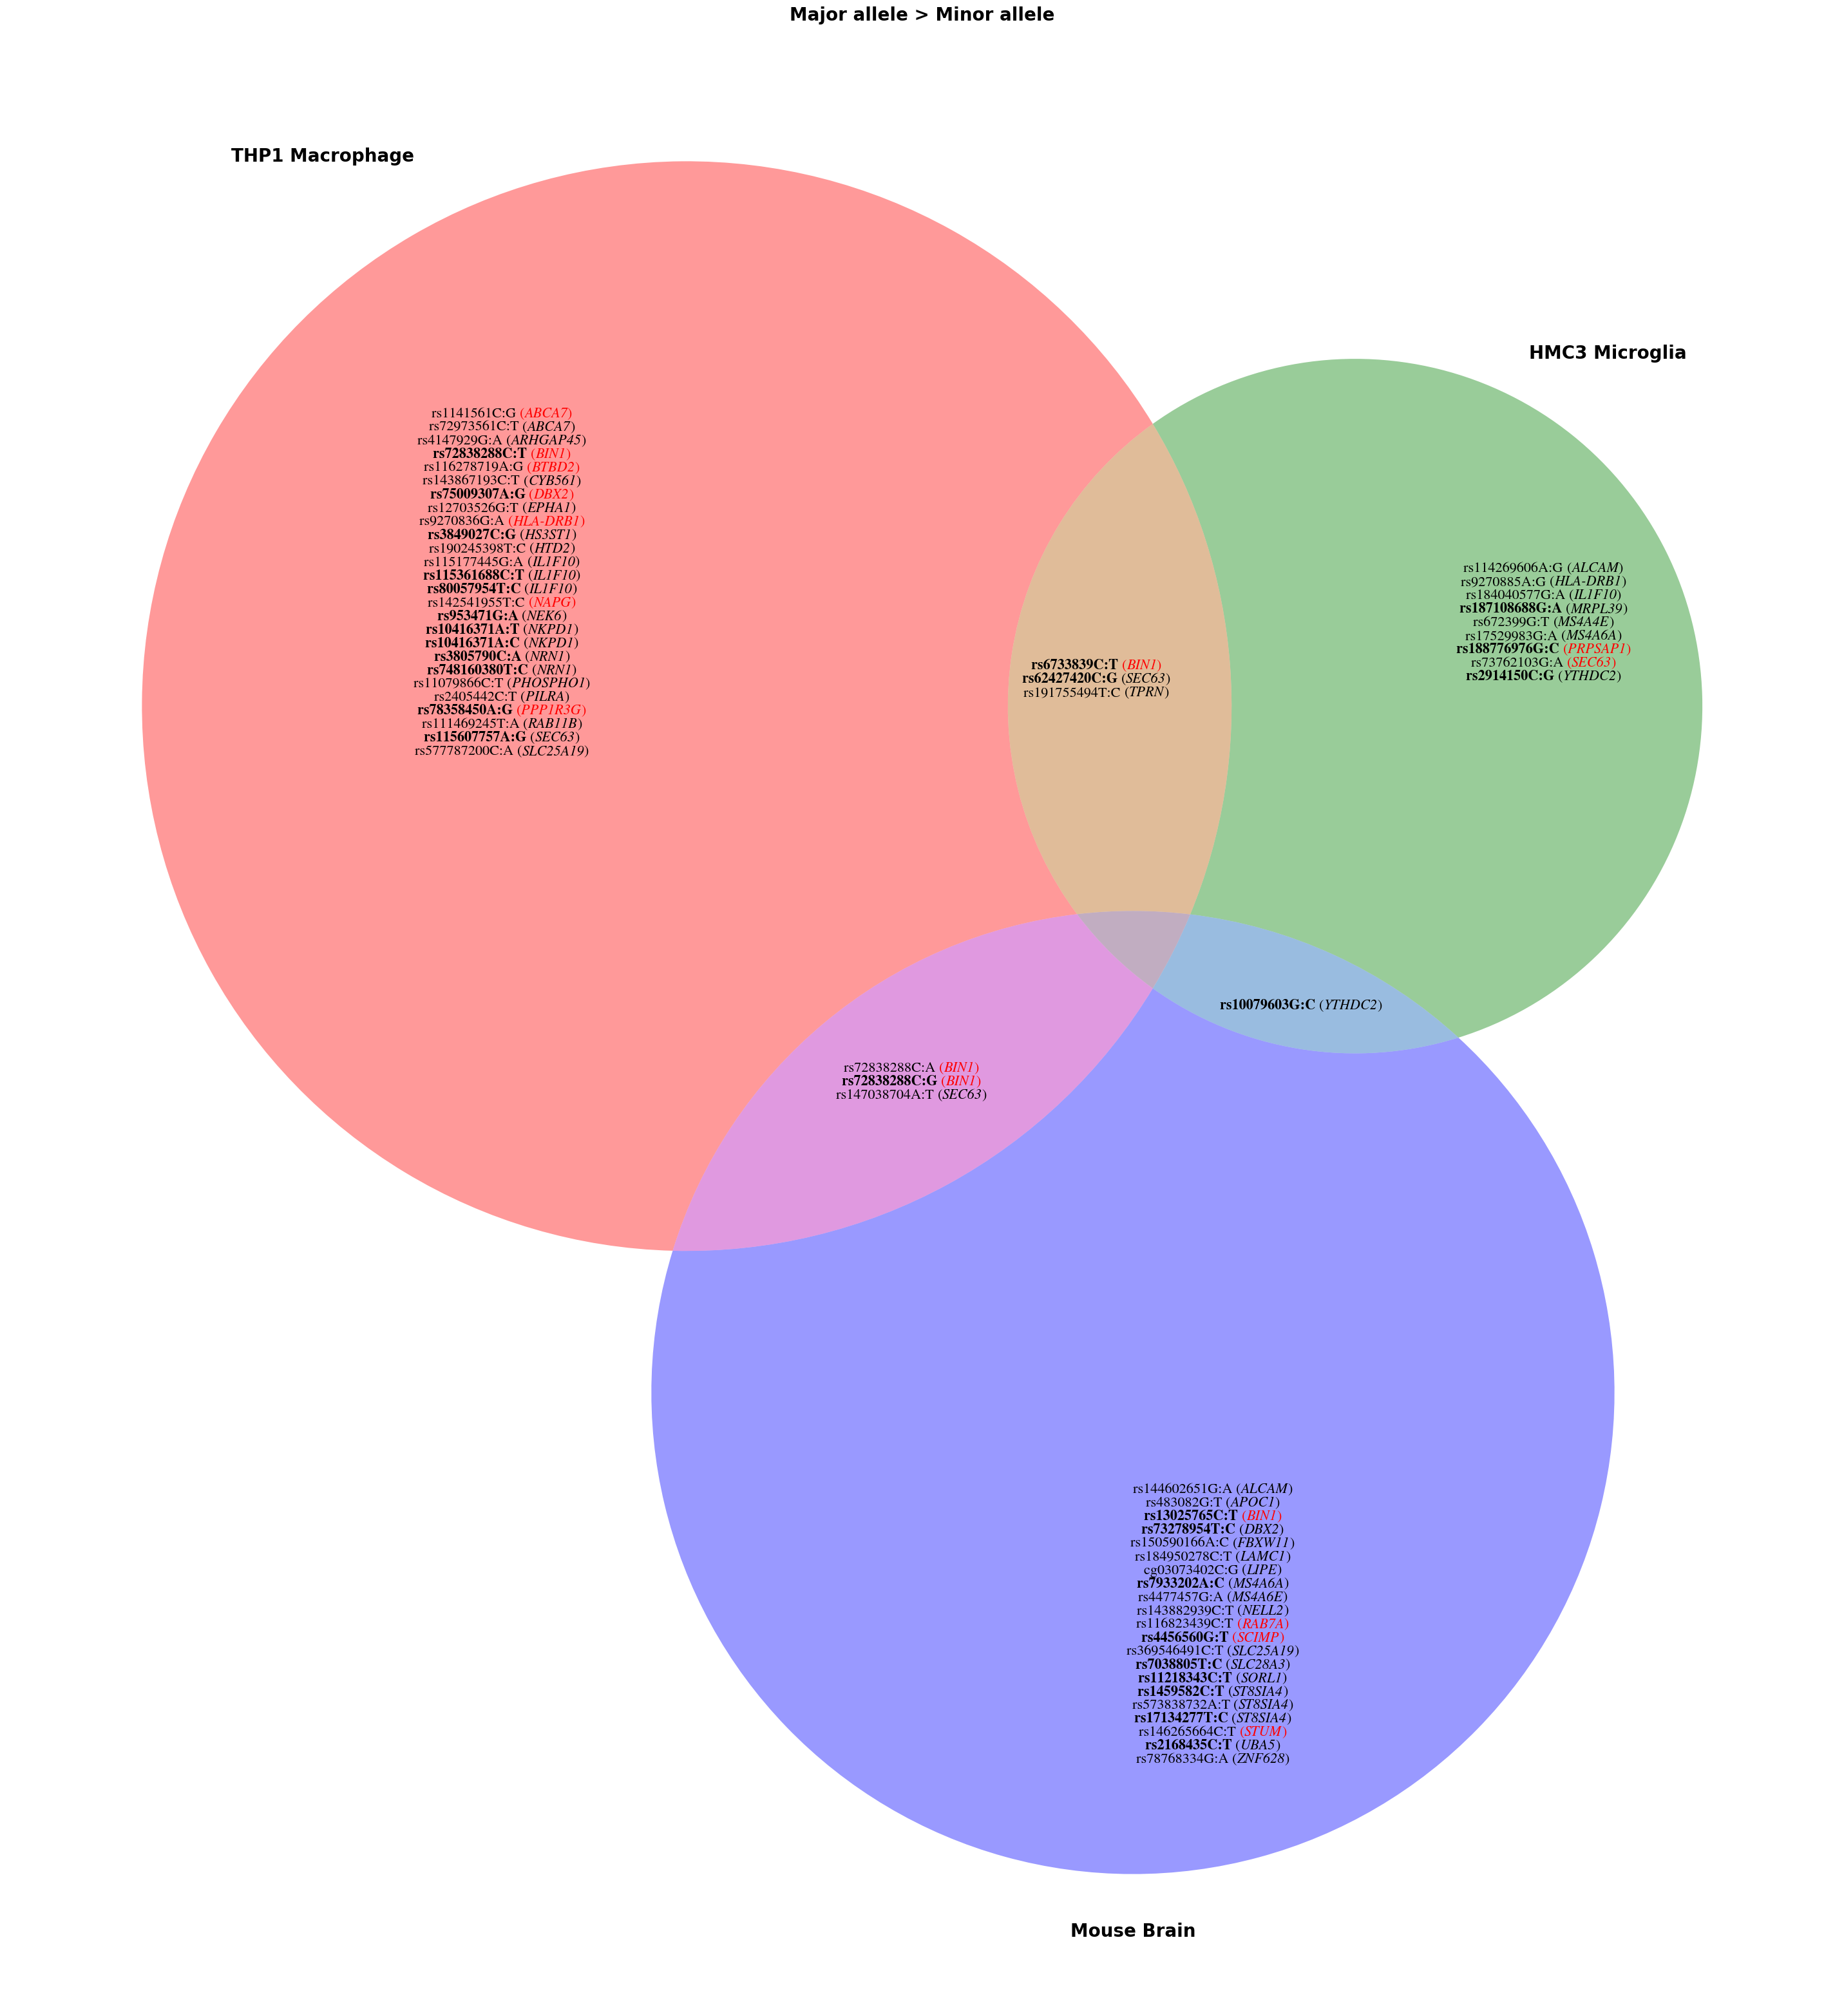

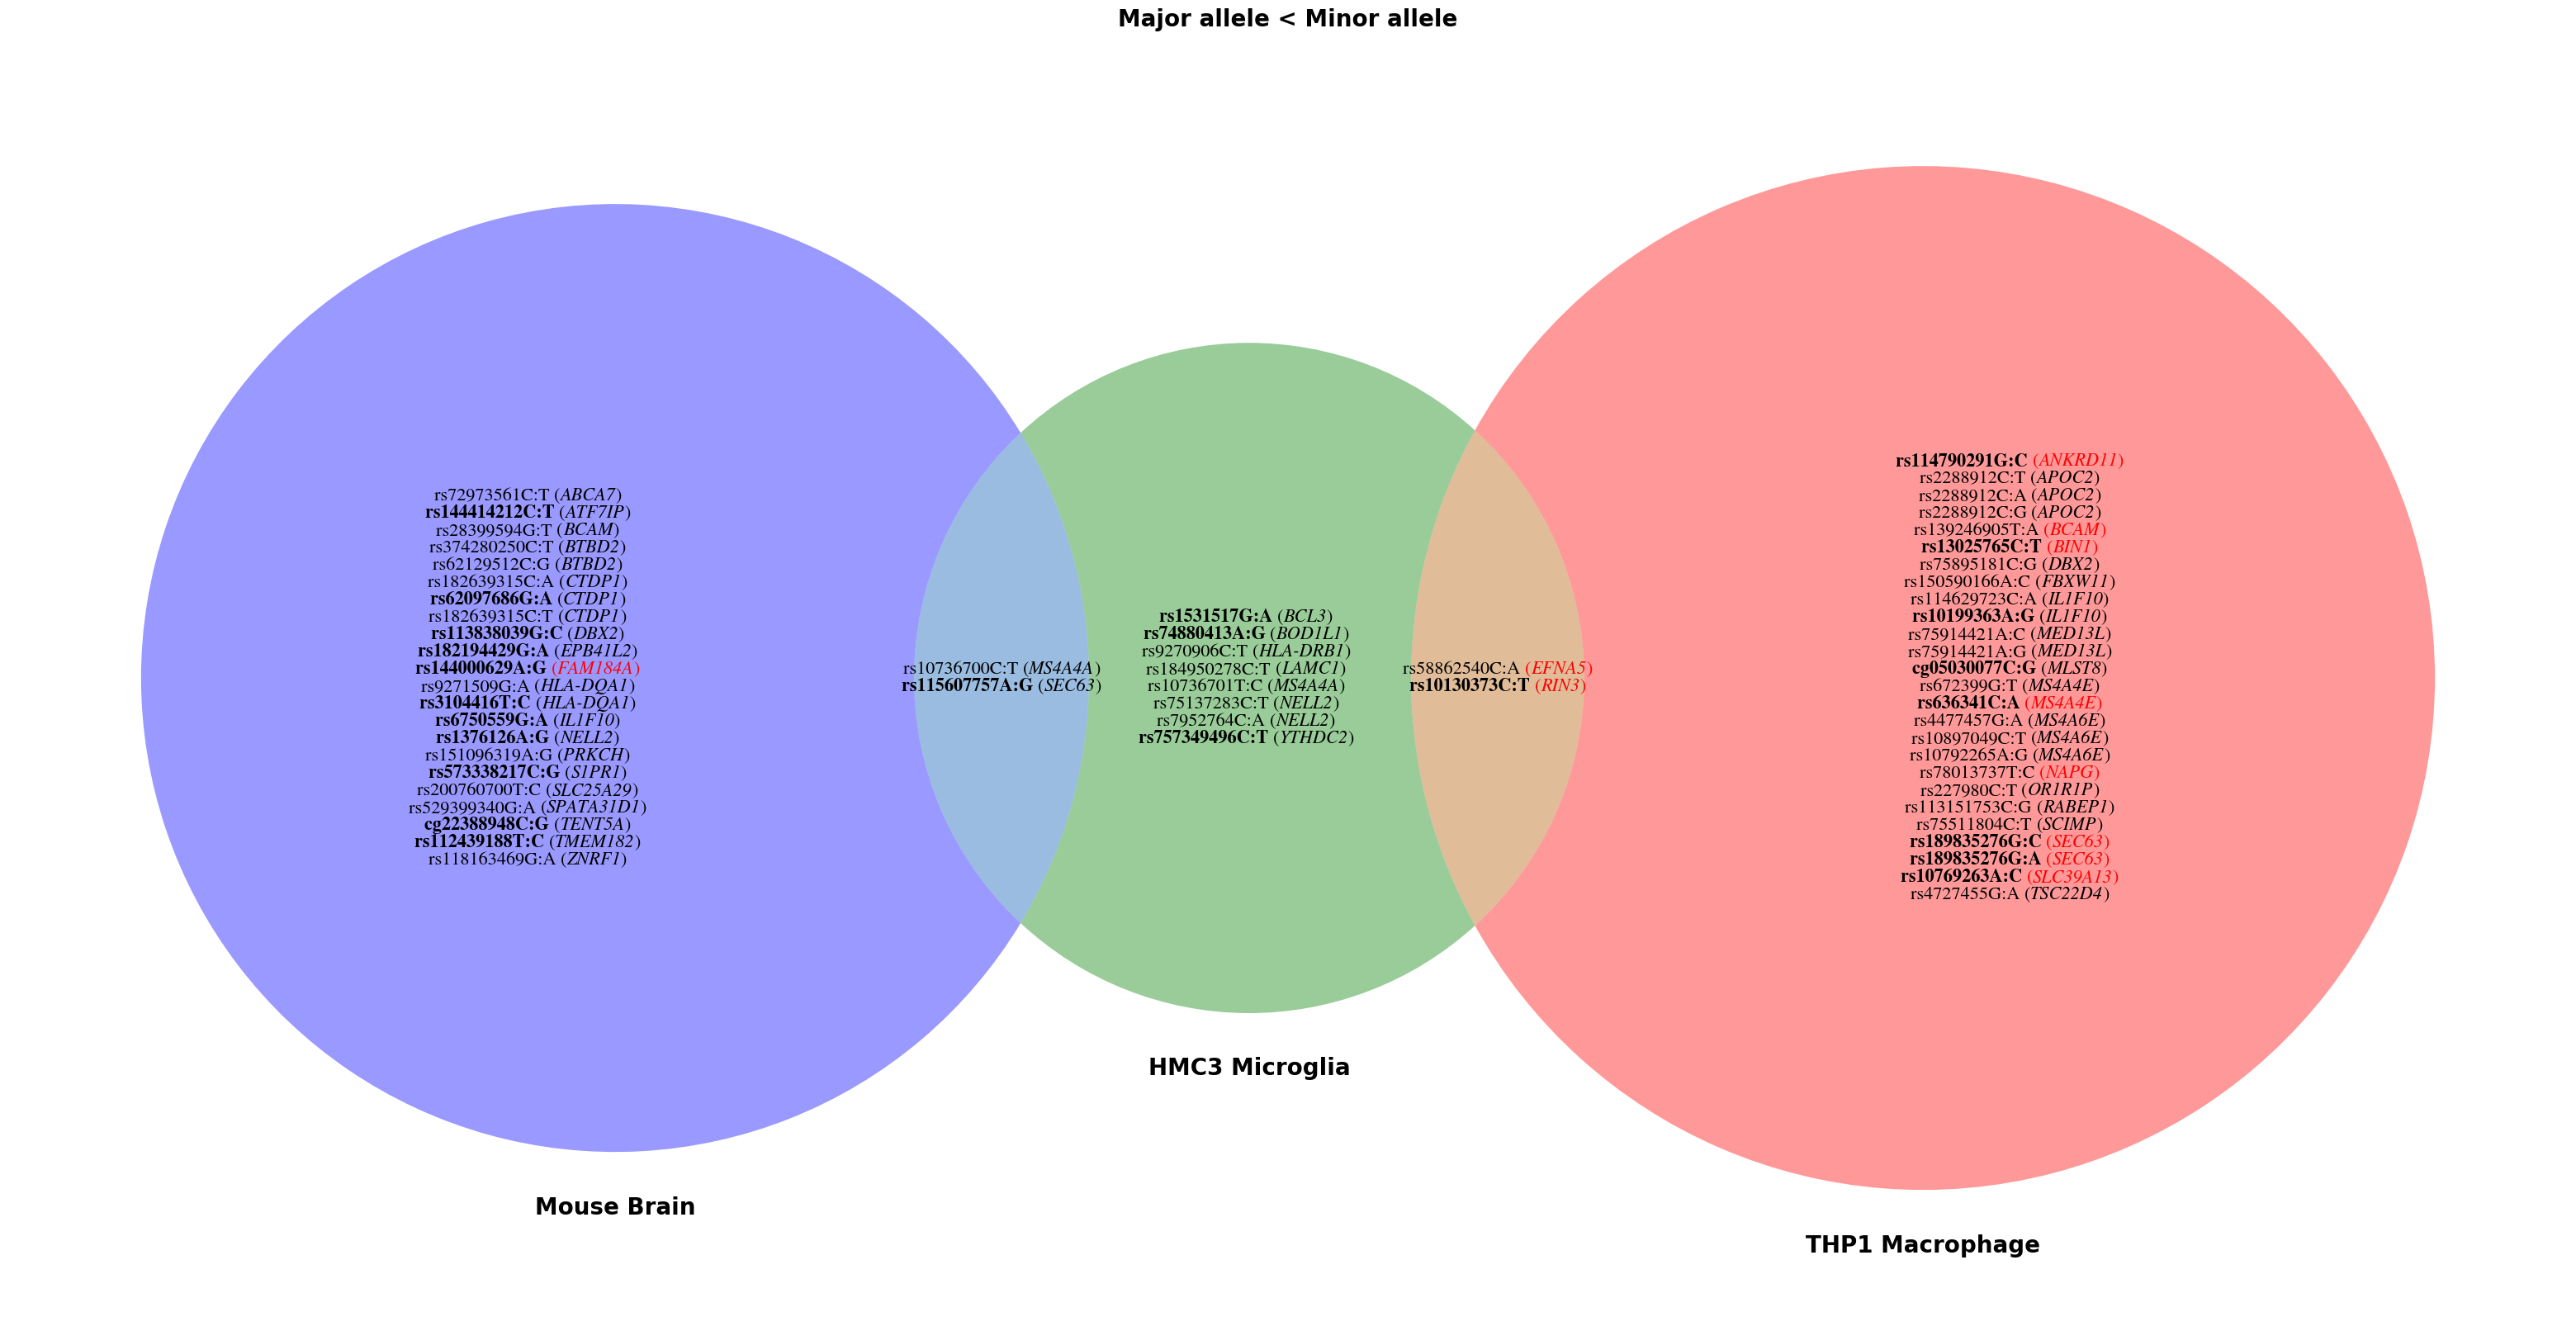

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from matplotlib.font_manager import FontProperties
from matplotlib.offsetbox import TextArea, HPacker, VPacker, AnnotationBbox


# ============================================================
# Global font settings
# Apply these settings BEFORE drawing either figure so that the
# two exported PDFs use the same font configuration.
# ============================================================
plt.rcParams['text.usetex'] = False  # Keep False to use matplotlib's built-in rendering
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'DejaVu Sans'

# Font used for the RSID lines inside the Venn-diagram circles.
# STIXGeneral gives a serif appearance similar to the original figure.
RSID_FONT_FAMILY = 'STIXGeneral'
RSID_FONT_SIZE = 16
SET_LABEL_FONT_SIZE = 20
TITLE_FONT_SIZE = 20


# ============================================================
# Hard-coded red annotations
# Match by rsID only, rather than by the entire rsid_gene_tss string.
# This is more robust because allele and annotation formatting may differ
# slightly across CSV files. Only the listed rsIDs will be colored red.
# ============================================================
RED_RSID_IDS_MAJOR_GREATER_MINOR = {
    # THP-1 Macrophages only
    'rs1141561',
    'rs72838288',
    'rs116278719',
    'rs75009307',
    'rs9270836',
    'rs142541955',
    'rs78358450',

    # HMC3 Microglia only
    'rs188776976',
    'rs73762103',

    # THP-1 Macrophages and HMC3 Microglia overlap
    'rs6733839',

    # Brain Tissue only
    'rs13025765',
    'rs116823439',
    'rs4456560',
    'rs146265664',
}

RED_RSID_IDS_MAJOR_LESS_MINOR = {
    # Brain Tissue only
    'rs144000629',

    # HMC3 Microglia and THP-1 Macrophages overlap
    'rs58862540',
    'rs10130373',

    # THP-1 Macrophages only
    'rs114790291',
    'rs139246905',
    'rs13025765',
    'rs636341',
    'rs78013737',
    'rs189835276',
    'rs10769263',
}


# ============================================================
# Load ML-supported variants
# ============================================================
df_ml = pd.read_csv(
    'indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_20250608.csv',
    index_col=0
)

#df_ml_sig_brain = df_ml[[       
#       'ML_majorminor_logFC_genomic_Mouse_Cortex_AgeB-model',
#       'ML_majorminor_logFC_genomic_Mouse_Cortex_AgeC-model',
#       'ML_majorminor_logFC_genomic_Mouse_Striatum_AgeB',
#       'ML_majorminor_logFC_genomic_Mouse_Striatum_AgeC',
#       'ML_majorminor_diff_genomic_Mouse_Cortex_AgeB-model',
#       'ML_majorminor_diff_genomic_Mouse_Cortex_AgeC-model',
#       'ML_majorminor_diff_genomic_Mouse_Striatum_AgeB',
#       'ML_majorminor_diff_genomic_Mouse_Striatum_AgeC',
#       ]].dropna(how='all')

# Human neuronal models used for variants detected in mouse-brain MPRA.
df_ml_sig_brain = df_ml[[       
       'ML_majorminor_logFC_genomic_fullard_DLPFC-model-best',
       'ML_majorminor_logFC_genomic_fullard_hippocampus-model-best',
       'ML_majorminor_logFC_genomic_fullard_putamen-model-best',
       'ML_majorminor_diff_genomic_fullard_DLPFC-model-best',
       'ML_majorminor_diff_genomic_fullard_hippocampus-model-best',
       'ML_majorminor_diff_genomic_fullard_putamen-model-best',
       ]].dropna(how='all')

# THP-1 macrophage models used for variants detected in THP-1 or HMC3 MPRA.
df_ml_sig_immune = df_ml[[ 
       'ML_majorminor_logFC_genomic_THP1_IFNB-Calvin',
       'ML_majorminor_logFC_genomic_THP1_IFNG-Calvin',
       'ML_majorminor_logFC_genomic_THP1_LPSIFNG-Calvin',     
       'ML_majorminor_logFC_genomic_THP1_Naive-Calvin',
       'ML_majorminor_diff_genomic_THP1_IFNB-Calvin',
       'ML_majorminor_diff_genomic_THP1_IFNG-Calvin',
       'ML_majorminor_diff_genomic_THP1_LPSIFNG-Calvin',     
       'ML_majorminor_diff_genomic_THP1_Naive-Calvin',
       ]].dropna(how='all')

# Use sets for fast membership testing.
df_ml_sig_brain_rsid = set(
    df_ml.loc[df_ml_sig_brain.index, 'rsid_gene_tss'].dropna().tolist()
)

df_ml_sig_immune_rsid = set(
    df_ml.loc[df_ml_sig_immune.index, 'rsid_gene_tss'].dropna().tolist()
)


# ============================================================
# Shared helper functions
# ============================================================
def extract_gene_name(rsid_str):
    """
    Extract the gene name inside parentheses for sorting.
    """
    match = re.search(r'\((.*?)\)', rsid_str)
    if match:
        return match.group(1)
    else:
        return rsid_str  # Return the whole string if no gene name is found


def extract_rsid_id(rsid_str):
    """
    Extract only the rsID portion, such as rs6733839, from a full label
    such as rs6733839C:T(BIN1). This avoids exact-string mismatches caused
    by allele or annotation formatting differences.
    """
    match = re.search(r'rs\d+', str(rsid_str))
    if match:
        return match.group(0)
    else:
        return str(rsid_str)


def is_ml_supported(rsid_str, rsid_THP1, rsid_HMC3, rsid_Brain):
    """
    Determine whether an RSID should be bold based on ML support.

    1) Variants detected in mouse-brain MPRA are evaluated using
       human neuronal models.

    2) Variants detected in THP-1 macrophages or HMC3 cells are
       evaluated using THP-1 macrophage models.

    3) For variants detected in multiple MPRA contexts, support
       from either corresponding model group is sufficient.
    """
    brain_supported = (
        rsid_str in rsid_Brain and
        rsid_str in df_ml_sig_brain_rsid
    )

    immune_supported = (
        (rsid_str in rsid_HMC3 or rsid_str in rsid_THP1) and
        rsid_str in df_ml_sig_immune_rsid
    )

    return brain_supported or immune_supported


def make_text_area(
    text,
    fontsize,
    color='black',
    weight='normal',
    style='normal'
):
    """
    Make one text segment for an RSID label.
    """
    font_properties = FontProperties(
        family=RSID_FONT_FAMILY,
        size=fontsize,
        weight=weight,
        style=style
    )

    return TextArea(
        text,
        textprops={
            'fontproperties': font_properties,
            'color': color
        }
    )


def make_rsid_line_box(rsid_str, should_bold=False, should_red=False, fontsize=16):
    """
    Create one RSID line as independently formatted text segments.

    - The RSID and allele text remain black.
    - The gene symbol and its parentheses become red only for the
      explicitly hard-coded labels.
    - The gene symbol remains italicized.
    - ML-supported RSID and allele text are bold.
    """
    rsid_weight = 'bold' if should_bold else 'normal'
    match = re.match(r'(.*?)(\((.*?)\))(.*)', rsid_str)

    if match:
        before_paren = match.group(1)
        gene_name = match.group(3)
        after_paren = match.group(4)

        gene_color = 'red' if should_red else 'black'

        pieces = [
            make_text_area(
                before_paren,
                fontsize=fontsize,
                color='black',
                weight=rsid_weight,
                style='normal'
            ),
            make_text_area(
                '(',
                fontsize=fontsize,
                color=gene_color,
                weight='normal',
                style='normal'
            ),
            make_text_area(
                gene_name,
                fontsize=fontsize,
                color=gene_color,
                weight='normal',
                style='italic'
            ),
            make_text_area(
                ')',
                fontsize=fontsize,
                color=gene_color,
                weight='normal',
                style='normal'
            ),
        ]

        if after_paren:
            pieces.append(
                make_text_area(
                    after_paren,
                    fontsize=fontsize,
                    color='black',
                    weight=rsid_weight,
                    style='normal'
                )
            )

    else:
        # No parentheses: keep the full label black.
        pieces = [
            make_text_area(
                rsid_str,
                fontsize=fontsize,
                color='black',
                weight=rsid_weight,
                style='normal'
            )
        ]

    return HPacker(
        children=pieces,
        align='baseline',
        pad=0,
        sep=0
    )


def prepare_venn_sets(df_THP1, df_HMC3, df_Brain):
    """
    Create the seven RSID subsets required by matplotlib_venn.venn3.
    """
    # Extract unique RSID values from each DataFrame
    rsid_THP1 = set(df_THP1['rsid_gene_tss'].dropna().unique())
    rsid_HMC3 = set(df_HMC3['rsid_gene_tss'].dropna().unique())
    rsid_Brain = set(df_Brain['rsid_gene_tss'].dropna().unique())

    # Prepare the RSID sets for each section
    only_THP1 = rsid_THP1 - rsid_HMC3 - rsid_Brain
    only_HMC3 = rsid_HMC3 - rsid_THP1 - rsid_Brain
    only_Brain = rsid_Brain - rsid_THP1 - rsid_HMC3
    THP1_HMC3 = (rsid_THP1 & rsid_HMC3) - rsid_Brain
    THP1_Brain = (rsid_THP1 & rsid_Brain) - rsid_HMC3
    HMC3_Brain = (rsid_HMC3 & rsid_Brain) - rsid_THP1
    All_three = rsid_THP1 & rsid_HMC3 & rsid_Brain

    # The order corresponds to subset IDs:
    # 100, 010, 110, 001, 101, 011, 111
    sets = [
        sorted(only_THP1, key=extract_gene_name),
        sorted(only_HMC3, key=extract_gene_name),
        sorted(THP1_HMC3, key=extract_gene_name),
        sorted(only_Brain, key=extract_gene_name),
        sorted(THP1_Brain, key=extract_gene_name),
        sorted(HMC3_Brain, key=extract_gene_name),
        sorted(All_three, key=extract_gene_name)
    ]

    return rsid_THP1, rsid_HMC3, rsid_Brain, sets


def report_unmatched_red_rsids(red_rsid_id_set, rsid_THP1, rsid_HMC3, rsid_Brain, title):
    """
    Print any hard-coded red labels that do not exactly match an
    rsid_gene_tss value in the current figure.
    """
    all_rsids = rsid_THP1 | rsid_HMC3 | rsid_Brain
    all_rsid_ids = {extract_rsid_id(rsid) for rsid in all_rsids}
    unmatched = sorted(red_rsid_id_set - all_rsid_ids)

    if unmatched:
        print('\nWARNING: The following hard-coded red labels were not found in:')
        print(title)
        print('Check whether the strings exactly match df[\'rsid_gene_tss\'].')
        for rsid in unmatched:
            print('  -', rsid)


def annotate_venn(
    venn,
    sets,
    rsid_THP1,
    rsid_HMC3,
    rsid_Brain,
    red_rsid_id_set,
    fontsize=16,
    line_spacing=0
):
    """
    Replace the region-count labels with RSID labels.

    Each line is built from separate text segments, allowing only
    selected parenthetical gene symbols to become red.
    """
    ax = plt.gca()
    subset_ids = ['100', '010', '110', '001', '101', '011', '111']

    for idx, subset_id in enumerate(subset_ids):
        label = venn.get_label_by_id(subset_id)

        if label is None:
            continue

        # Use the original subset-label position as the center point.
        x, y = label.get_position()

        # Remove matplotlib_venn's original count label.
        label.set_text('')

        rsids = sets[idx]
        if not rsids:
            continue

        line_boxes = []

        for rsid in rsids:
            should_bold = is_ml_supported(
                rsid,
                rsid_THP1=rsid_THP1,
                rsid_HMC3=rsid_HMC3,
                rsid_Brain=rsid_Brain
            )

            should_red = extract_rsid_id(rsid) in red_rsid_id_set

            line_boxes.append(
                make_rsid_line_box(
                    rsid_str=rsid,
                    should_bold=should_bold,
                    should_red=should_red,
                    fontsize=fontsize
                )
            )

        multiline_box = VPacker(
            children=line_boxes,
            align='center',
            pad=0,
            sep=line_spacing
        )

        annotation_box = AnnotationBbox(
            multiline_box,
            (x, y),
            xycoords='data',
            box_alignment=(0.5, 0.5),
            frameon=False,
            pad=0
        )

        ax.add_artist(annotation_box)


def plot_venn(
    df_THP1,
    df_HMC3,
    df_Brain,
    title,
    output_pdf,
    red_rsid_id_set
):
    """
    Generate one Venn diagram using shared formatting settings.
    """
    rsid_THP1, rsid_HMC3, rsid_Brain, sets = prepare_venn_sets(
        df_THP1=df_THP1,
        df_HMC3=df_HMC3,
        df_Brain=df_Brain
    )

    report_unmatched_red_rsids(
        red_rsid_id_set=red_rsid_id_set,
        rsid_THP1=rsid_THP1,
        rsid_HMC3=rsid_HMC3,
        rsid_Brain=rsid_Brain,
        title=title
    )

    # Create the Venn diagram with increased figure size
    plt.figure(figsize=(40, 40))

    venn = venn3(
        [rsid_THP1, rsid_HMC3, rsid_Brain],
        ('THP1 Macrophage', 'HMC3 Microglia', 'Mouse Brain')
    )

    # Adjust font sizes and make only set labels bold
    for text in venn.set_labels:
        if text:
            text.set_fontsize(SET_LABEL_FONT_SIZE)
            text.set_fontweight('bold')

    for text in venn.subset_labels:
        if text:
            text.set_fontsize(RSID_FONT_SIZE)
            # Do not set font weight to bold for subset labels.
            # Bolding is controlled separately for each RSID line.

    # Annotate the Venn diagram with RSIDs sorted by gene name
    annotate_venn(
        venn=venn,
        sets=sets,
        rsid_THP1=rsid_THP1,
        rsid_HMC3=rsid_HMC3,
        rsid_Brain=rsid_Brain,
        red_rsid_id_set=red_rsid_id_set,
        fontsize=RSID_FONT_SIZE,
        line_spacing=0
    )

    # Set the title with bold font weight
    plt.title(
        title,
        fontsize=TITLE_FONT_SIZE,
        fontweight='bold'
    )

    # Save the figure to a PDF file
    plt.savefig(
        output_pdf,
        format='pdf',
        bbox_inches='tight',
        dpi=300
    )

    plt.show()
    plt.close()


# ============================================================
# Figure 1: Major allele > Minor allele
# ============================================================
# Read your CSV files into DataFrames
df_Brain = pd.read_csv(
    'causal_alleles/20241029_BrainR1R2merged20240404_Major_greater_Minor_case135_withMAD.csv',
    index_col=0
)

df_HMC3 = pd.read_csv(
    'causal_alleles/20241029_HMC3_Major_greater_Minor_case135_withMAD.csv',
    index_col=0
)

df_THP1 = pd.read_csv(
    'causal_alleles/20241029_THP1Macrophage_Major_greater_Minor_case135_withMAD.csv',
    index_col=0
)

df_case135 = pd.concat([df_Brain, df_HMC3, df_THP1])

# Create a dictionary to map rsid_gene to bold flag based on 'Case' == 1 or 3
# Retained as comment-out code for reference. The current figure uses
# ML-based bold annotation so that it matches the figure legend.
#rsid_bold_dict = {}
#
#for df in [df_THP1, df_HMC3, df_Brain]:
#    for rsid_gene in df['rsid_gene_tss'].unique():
#        df_subset = df[df['rsid_gene_tss'] == rsid_gene]
#        if any(df_subset['Case'].isin([1, 3])):
#            rsid_bold_dict[rsid_gene] = True
#        else:
#            # Keep existing True value if already set
#            rsid_bold_dict[rsid_gene] = rsid_bold_dict.get(rsid_gene, False)

plot_venn(
    df_THP1=df_THP1,
    df_HMC3=df_HMC3,
    df_Brain=df_Brain,
    title='Major allele > Minor allele',
    output_pdf='venn_diagram_major_greater_minor_ml_neuron.pdf',
    red_rsid_id_set=RED_RSID_IDS_MAJOR_GREATER_MINOR
)


# ============================================================
# Figure 2: Major allele < Minor allele
# ============================================================
# Read your CSV files into DataFrames
df_Brain = pd.read_csv(
    'causal_alleles/20241029_BrainR1R2merged20240404_Major_less_Minor_case246_withMAD.csv',
    index_col=0
)

df_HMC3 = pd.read_csv(
    'causal_alleles/20241029_HMC3_Major_less_Minor_case246_withMAD.csv',
    index_col=0
)

df_THP1 = pd.read_csv(
    'causal_alleles/20241029_THP1Macrophage_Major_less_Minor_case246_withMAD.csv',
    index_col=0
)

df_case246 = pd.concat([df_Brain, df_HMC3, df_THP1])

# Create a dictionary to map rsid_gene to bold flag based on 'Case' == 2 or 4
# Retained as comment-out code for reference. The current figure uses
# ML-based bold annotation so that it matches the figure legend.
#rsid_bold_dict = {}
#
#for df in [df_THP1, df_HMC3, df_Brain]:
#    for rsid_gene in df['rsid_gene_tss'].unique():
#        df_subset = df[df['rsid_gene_tss'] == rsid_gene]
#        if any(df_subset['Case'].isin([2, 4])):
#            rsid_bold_dict[rsid_gene] = True
#        else:
#            # Keep existing True value if already set
#            rsid_bold_dict[rsid_gene] = rsid_bold_dict.get(rsid_gene, False)

plot_venn(
    df_THP1=df_THP1,
    df_HMC3=df_HMC3,
    df_Brain=df_Brain,
    title='Major allele < Minor allele',
    output_pdf='venn_diagram_major_less_minor_ml_neuron.pdf',
    red_rsid_id_set=RED_RSID_IDS_MAJOR_LESS_MINOR
)


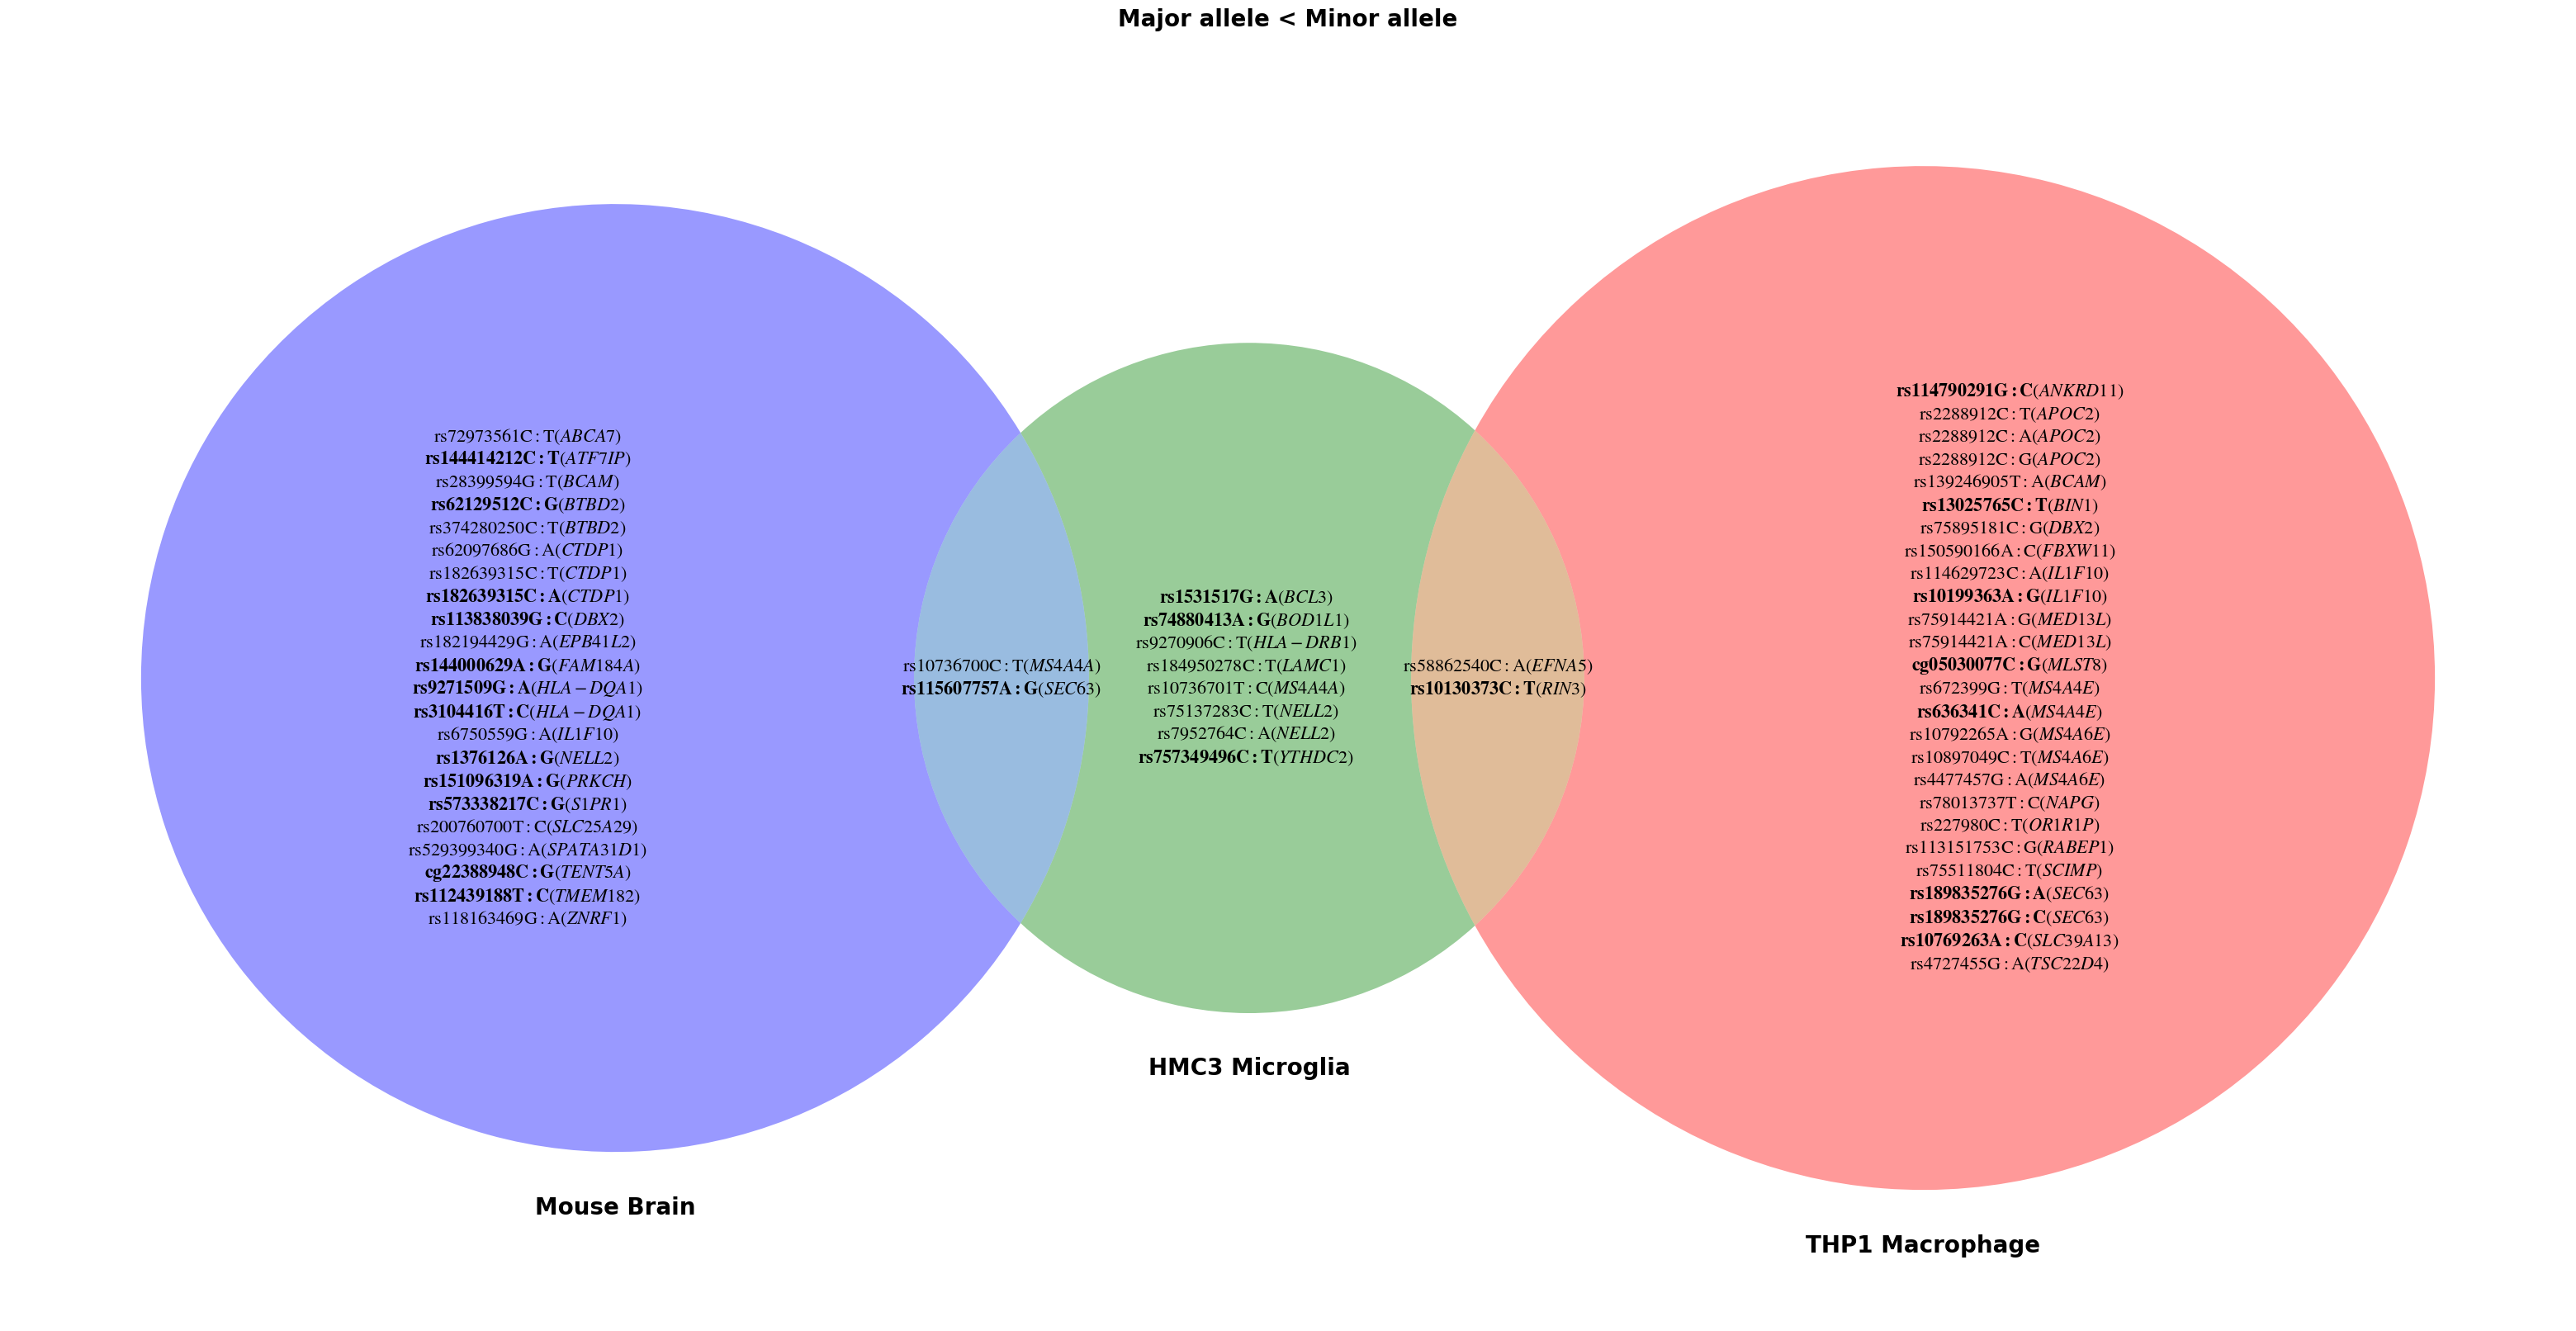

In [34]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Read your CSV files into DataFrames
df_Brain = pd.read_csv('causal_alleles/20241029_BrainR1R2merged20240404_Major_less_Minor_case246_withMAD.csv', index_col=0)
df_HMC3 = pd.read_csv('causal_alleles/20241029_HMC3_Major_less_Minor_case246_withMAD.csv', index_col=0)
df_THP1 = pd.read_csv('causal_alleles/20241029_THP1Macrophage_Major_less_Minor_case246_withMAD.csv', index_col=0)
df_case246 = pd.concat([df_Brain,df_HMC3,df_THP1])
# Extract unique RSID values from each DataFrame
rsid_THP1 = set(df_THP1['rsid_gene_tss'].unique())
rsid_HMC3 = set(df_HMC3['rsid_gene_tss'].unique())
rsid_Brain = set(df_Brain['rsid_gene_tss'].unique())

# Prepare the RSID sets for each section
only_THP1 = rsid_THP1 - rsid_HMC3 - rsid_Brain
only_HMC3 = rsid_HMC3 - rsid_THP1 - rsid_Brain
only_Brain = rsid_Brain - rsid_THP1 - rsid_HMC3
THP1_HMC3 = (rsid_THP1 & rsid_HMC3) - rsid_Brain
THP1_Brain = (rsid_THP1 & rsid_Brain) - rsid_HMC3
HMC3_Brain = (rsid_HMC3 & rsid_Brain) - rsid_THP1
All_three = rsid_THP1 & rsid_HMC3 & rsid_Brain

# Create a dictionary to map rsid_gene to bold flag based on 'Case' == 1 or 3
rsid_bold_dict = {}

for df in [df_THP1, df_HMC3, df_Brain]:
    for rsid_gene in df['rsid_gene_tss'].unique():
        df_subset = df[df['rsid_gene_tss'] == rsid_gene]
        if any(df_subset['Case'].isin([2, 4])):
            rsid_bold_dict[rsid_gene] = True
        else:
            # Keep existing True value if already set
            rsid_bold_dict[rsid_gene] = rsid_bold_dict.get(rsid_gene, False)

# Function to extract gene name from RSID string
def extract_gene_name(rsid_str):
    match = re.search(r'\((.*?)\)', rsid_str)
    if match:
        return match.group(1)
    else:
        return rsid_str  # Return the whole string if no gene name is found


def format_rsid_gene(rsid_str):
    """
    1) If rsid_str is in rsid_Brain & df_ml_sig_brain_rsid OR 
       in (rsid_HMC3 or rsid_THP1) & df_ml_sig_immune_rsid, 
       then we set should_bold = True.
    2) If the RSID string has parentheses, italicize the gene inside parentheses
       and either bold or \mathrm the rest.
    3) If no parentheses, just bold or leave unformatted (escaped).
    """
    # Determine whether this RSID should be bold
    if rsid_str in rsid_Brain and rsid_str in df_ml_sig_brain_rsid.tolist():
        should_bold = True
    elif (rsid_str in rsid_HMC3 or rsid_str in rsid_THP1) and rsid_str in df_ml_sig_immune_rsid.tolist():
        should_bold = True
    else:
        should_bold = False

    # Regex to capture: text before '(', the parentheses with gene, text after ')'
    match = re.match(r'(.*?)(\((.*?)\))(.*)', rsid_str)
    if match:
        before_paren = match.group(1)   # text before '('
        paren_content = match.group(2) # entire parenthetical portion (includes '(' and ')')
        gene_name = match.group(3)     # text inside parentheses
        after_paren = match.group(4)   # text after ')'

        # Escape underscores
        before_paren = before_paren.replace('_', r'\_')
        gene_name = gene_name.replace('_', r'\_')
        after_paren = after_paren.replace('_', r'\_')

        # Italicize the gene name inside parentheses
        gene_name_formatted = r'\mathit{' + gene_name + '}'
        paren_content_formatted = '(' + gene_name_formatted + ')'

        # Bold or upright for the portions outside parentheses
        if should_bold:
            before_paren = r'\mathbf{' + before_paren + '}'
            after_paren = r'\mathbf{' + after_paren + '}'
        else:
            # Use upright (mathrm)
            before_paren = r'\mathrm{' + before_paren + '}'
            after_paren = r'\mathrm{' + after_paren + '}'

        # Combine the pieces
        formatted_rsid = before_paren + paren_content_formatted + after_paren

    else:
        # No parentheses, just escape underscores
        escaped = rsid_str.replace('_', r'\_')
        if should_bold:
            formatted_rsid = r'\mathbf{' + escaped + '}'
        else:
            # If not bold, use upright or leave alone.
            formatted_rsid = r'\mathrm{' + escaped + '}'

    # Wrap in $...$ to render as math text
    formatted_rsid = '$' + formatted_rsid + '$'
    return formatted_rsid



# Create the Venn diagram with increased figure size
plt.figure(figsize=(40, 40))  # Increase the figure size for better readability
venn = venn3([rsid_THP1, rsid_HMC3, rsid_Brain], ('THP1 Macrophage', 'HMC3 Microglia', 'Mouse Brain'))

# Adjust font sizes and make only set labels bold
for text in venn.set_labels:
    text.set_fontsize(20)
    text.set_fontweight('bold')  # Make the set labels bold
for text in venn.subset_labels:
    if text:
        text.set_fontsize(16)
        # Do not set font weight to bold for subset labels

# Annotate the Venn diagram with RSIDs sorted by gene name and formatted accordingly
def annotate_venn(venn, sets):
    subset_ids = ['100', '010', '110', '001', '101', '011', '111']
    for idx, subset_id in enumerate(subset_ids):
        label = venn.get_label_by_id(subset_id)
        if label:
            rsids = sets[idx]
            if rsids:
                # Format each RSID string
                rsids_formatted = [format_rsid_gene(rsid) for rsid in rsids]
                # Join RSIDs with line breaks for display
                label.set_text('\n'.join(rsids_formatted))
            else:
                label.set_text('')

# Create a list of sorted RSID lists corresponding to Venn diagram subsets
sets = [
    sorted(only_THP1, key=extract_gene_name),
    sorted(only_HMC3, key=extract_gene_name),
    sorted(THP1_HMC3, key=extract_gene_name),
    sorted(only_Brain, key=extract_gene_name),
    sorted(THP1_Brain, key=extract_gene_name),
    sorted(HMC3_Brain, key=extract_gene_name),
    sorted(All_three, key=extract_gene_name)
]

# Annotate the Venn diagram
annotate_venn(venn, sets)

# Set the title with bold font weight
plt.title('Major allele < Minor allele', fontsize=20, fontweight='bold')

# Enable LaTeX-style math text rendering
plt.rcParams['text.usetex'] = False  # Keep False to use matplotlib's built-in math rendering
plt.rcParams['mathtext.fontset'] = 'stix'

# Save the figure to a PDF file
plt.savefig('venn_diagram_major_less_minor_ml.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()


In [29]:
#!/usr/bin/env python3
"""
Clean every causal‑allele CSV in SRC_DIR and write a simplified
version to SRC_DIR/simplified.

• Ensures all desired columns exist (adds NA when missing)
• Renames BEFORE re‑ordering so the final layout is stable
• Warns when expected columns are absent
"""

from pathlib import Path
import pandas as pd
import numpy as np

# ── Paths ───────────────────────────────────────────────────────────────
SRC_DIR = Path("/media/zihengc/T7/mpra3_lib_analysis/causal_alleles")
DST_DIR = SRC_DIR / "simplified"
DST_DIR.mkdir(exist_ok=True)

# ── Rename map ───────────────────────────────────────────────────────────
RENAME = {
    "rsid_gene_label": "rsid_nearestTSS_annotation",
    #"statistics":       "MPRA_test_statistics",   # plural form
    "pval":             "MPRA_test_pval",
    "fdr":              "MPRA_test_fdr",
    "SNP_Function":     "CRE_annotation",
    "Bellenguez_p_value_negLog10": "GWAS_Bellenguez_p_value_negLog10",
    "logFC_converted":"logFC_Major_Minor"
}

# ── Final column order ───────────────────────────────────────────────────
COLS_FINAL = [
    "id","Category", "MPRA_test_pval", "MPRA_test_fdr",
    "logFC_Major_Minor", "RSID", "chr_number", "pos_hg38",
    "Major", "Minor", "nearest_gene", "rsid_nearestTSS_annotation",
    "closest_protein_coding_gene_TSS", "hierarchical_label",
    "CRE_annotation", "Rare_Common",
    "EUR", "AFR", "AMR", "ASN",
    "GWAS_Bellenguez_p_value_negLog10",
    "mad.score.minor", "mad.score.major",
    "pval.mad.minor", "pval.mad.major",
]

    # ------------------------------------------------------------------
# 1.  Hard‑coded renames for the 16 “ML_majorminor_diff_genomic_*” columns
# ------------------------------------------------------------------
ML_RENAME = {
    # H1 microglia
    "ML_majorminor_diff_genomic_H1_IFNB-model"          : "H1_Microglia_IFNB_ML_Diff",
    "ML_majorminor_diff_genomic_H1_resting-model"       : "H1_Microglia_resting_ML_Diff",

    # HEK293
    "ML_majorminor_diff_genomic_HEK293T_ATAC"           : "HEK293T_ML_Diff",
    "ML_majorminor_diff_genomic_HEK293_ATAC_high_depth0729": "HEK293_ML_Diff",

    # Mouse cortex & striatum
    "ML_majorminor_diff_genomic_Mouse_Cortex_AgeB-model": "Mouse_Cortex_AgeB_ML_Diff",
    "ML_majorminor_diff_genomic_Mouse_Cortex_AgeC-model": "Mouse_Cortex_AgeC_ML_Diff",
    "ML_majorminor_diff_genomic_Mouse_Striatum_AgeB"    : "Mouse_Striatum_AgeB_ML_Diff",
    "ML_majorminor_diff_genomic_Mouse_Striatum_AgeC"    : "Mouse_Striatum_AgeC_ML_Diff",

    # THP‑1 macrophage / monocyte
    "ML_majorminor_diff_genomic_THP1_IFNB-Calvin"       : "THP1_IFNb_ML_Diff",
    "ML_majorminor_diff_genomic_THP1_IFNG-Calvin"       : "THP1_IFNg_ML_Diff",
    "ML_majorminor_diff_genomic_THP1_LPSIFNG-Calvin"    : "THP1_LPSIFNg_ML_Diff",
    "ML_majorminor_diff_genomic_THP1_Naive-Calvin"      : "THP1_Resting_ML_Diff",
    "ML_majorminor_diff_genomic_THP1_monocyte0729"      : "THP1_monocyte_ML_Diff",

    # WTC11 iPSC‑derived microglia
    "ML_majorminor_diff_genomic_WTC11_IFNB"             : "WTC11_microglia_IFNb_ML_Diff",
     "ML_majorminor_diff_genomic_WTC11_resting"        : "WTC11_microglia_resting_ML_Diff",


    # H1 microglia
    "ML_majorminor_logFC_genomic_H1_IFNB-model"          : "H1_Microglia_IFNB_ML_logFC",
    "ML_majorminor_logFC_genomic_H1_resting-model"       : "H1_Microglia_resting_ML_logFC",

    # HEK293
    "ML_majorminor_logFC_genomic_HEK293T_ATAC"           : "HEK293T_ML_logFC",
    "ML_majorminor_logFC_genomic_HEK293_ATAC_high_depth0729": "HEK293_ML_logFC",

    # Mouse cortex & striatum
    "ML_majorminor_logFC_genomic_Mouse_Cortex_AgeB-model": "Mouse_Cortex_AgeB_ML_logFC",
    "ML_majorminor_logFC_genomic_Mouse_Cortex_AgeC-model": "Mouse_Cortex_AgeC_ML_logFC",
    "ML_majorminor_logFC_genomic_Mouse_Striatum_AgeB"    : "Mouse_Striatum_AgeB_ML_logFC",
    "ML_majorminor_logFC_genomic_Mouse_Striatum_AgeC"    : "Mouse_Striatum_AgeC_ML_logFC",

    # THP‑1 macrophage / monocyte
    "ML_majorminor_logFC_genomic_THP1_IFNB-Calvin"       : "THP1_IFNb_ML_logFC",
    "ML_majorminor_logFC_genomic_THP1_IFNG-Calvin"       : "THP1_IFNg_ML_logFC",
    "ML_majorminor_logFC_genomic_THP1_LPSIFNG-Calvin"    : "THP1_LPSIFNg_ML_logFC",
    "ML_majorminor_logFC_genomic_THP1_Naive-Calvin"      : "THP1_Resting_ML_logFC",
    "ML_majorminor_logFC_genomic_THP1_monocyte0729"      : "THP1_monocyte_ML_logFC",

    # WTC11 iPSC‑derived microglia
    "ML_majorminor_logFC_genomic_WTC11_IFNB"             : "WTC11_microglia_IFNb_ML_logFC",
     "ML_majorminor_logFC_genomic_WTC11_resting"        : "WTC11_microglia_resting_ML_logFC",
}

ML_ORDER = [
    "Mouse_Cortex_AgeB_ML_Diff", "Mouse_Cortex_AgeC_ML_Diff",
    "Mouse_Striatum_AgeB_ML_Diff", "Mouse_Striatum_AgeC_ML_Diff",
    "THP1_IFNB_ML_Diff", "THP1_IFNG_ML_Diff", "THP1_LPSIFNG_ML_Diff",
    "THP1_Naive_ML_Diff", "THP1_monocyte_ML_Diff",
    "WTC11_microglia_IFNB_ML_Diff", "WTC11_microglia_resting_ML_Diff",
    "H1_Microglia_IFNB_ML_Diff", "H1_Microglia_resting_ML_Diff",
    "HEK293T_ML_Diff", "HEK293_ML_Diff",

    "Mouse_Cortex_AgeB_ML_logFC", "Mouse_Cortex_AgeC_ML_logFC",
    "Mouse_Striatum_AgeB_ML_logFC", "Mouse_Striatum_AgeC_ML_logFC",
    "THP1_IFNB_ML_logFC", "THP1_IFNG_ML_logFC", "THP1_LPSIFNG_ML_logFC",
    "THP1_Naive_ML_logFC", "THP1_monocyte_ML_logFC",
    "WTC11_microglia_IFNB_ML_logFC", "WTC11_microglia_resting_ML_logFC",
    "H1_Microglia_IFNB_ML_logFC", "H1_Microglia_resting_ML_logFC",
    "HEK293T_ML_logFC", "HEK293_ML_logFC",
]

# ── Helper to ensure missing columns are present ─────────────────────────
def ensure_columns(df, columns):
    missing = [c for c in columns if c not in df.columns]
    for col in missing:
        df[col] = np.nan        # or '' if you prefer empty string
    return df

df_index = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_20250608.csv',index_col=0 )

# ── Main loop ────────────────────────────────────────────────────────────
for csv_path in SRC_DIR.glob("*.csv"):
    df = pd.read_csv(csv_path)

    # First column → id
    df.rename(columns={df.columns[0]: "id"}, inplace=True)

    # 1) explicit renames (pval → MPRA_test_pval, etc.)
    df.rename(columns=RENAME,    inplace=True)
    # 2) ML_majorminor → short names
    df.rename(columns=ML_RENAME, inplace=True)

    # guarantee core columns
    df = ensure_columns(df, COLS_FINAL)

    # initial ordering of core block
    df = df[COLS_FINAL]

    # merge in the 16 ML columns from df_index (still old names here)
    df = pd.merge(
        df,
        df_index.loc[df["id"]].iloc[:, -30:-1],
        left_on="id",
        right_index=True,
    )

    # rename those freshly‑merged ML columns now
    df.rename(columns=ML_RENAME, inplace=True)

    # ------------------------------------------------------------------
    # **Put ML columns in the exact order required**
    # ------------------------------------------------------------------
    for col in ML_ORDER:                      # add missing ML cols as NaN
        if col not in df.columns:
            df[col] = np.nan

    ordered_cols = COLS_FINAL + ML_ORDER      # final layout
    df = df[ordered_cols]

    # save
    out_path = DST_DIR / csv_path.name
    df = df.set_index("id")
    df['Sum_ML'] = df.iloc[:, -30:-1].abs().sum(axis=1)
    df.to_csv(out_path, index=False)
    print(f"[ok] {csv_path.name} → simplified/{out_path.name}")
    print(df[df['Sum_ML']>0].sort_values('closest_protein_coding_gene_TSS')['rsid_nearestTSS_annotation'])



[ok] 20241029_HMC3_Major_greater_Minor_case135_withMAD.csv → simplified/20241029_HMC3_Major_greater_Minor_case135_withMAD.csv
id
alt:rs114269606:PEAKCENTER:chr3:105584898:A:G:105584362:105585294:105584875     rs114269606(ALCAM) distal_enhancer
alt:rs6733839:PEAKCENTER:chr2:127892810:C:T:127891990:127893319:127892710          rs6733839(BIN1) distal_enhancer
alt:rs9270885:PEAKCENTER:chr6:32571771:G:A:32571733:32572743:32571836          rs9270885(HLA-DRB1) distal_enhancer
alt:rs187108688:PEAKCENTER:chr21:24420973:G:A:24420664:24421005:24420900            rs187108688(MRPL39) intergenic
alt:rs672399:PEAKCENTER:chr11:60020112:T:G:60018954:60020211:60020089             rs672399(MS4A4E) distal_enhancer
alt:rs188776976:SNPCENTER:chr17:76351986:G:C:76351873:76352099:76351986              rs188776976(PRPSAP1) promoter
alt:rs62427420:SNPCENTER:chr6:108003170:C:G:108002774:108003244:108003075        rs62427420(SEC63) distal_enhancer
alt:rs62427420:PEAKCENTER:chr6:108003170:C:G:108002774:108003244:1

In [12]:
df_index.loc[df["id"]].iloc[:, -30:-1].abs().sum(axis=1)

alt:rs2288912:PEAKCENTER:chr19:44945942:C:A:44945662:44946162:44945912          0.00
alt:rs2288912:PEAKCENTER:chr19:44945942:C:T:44945662:44946162:44945912          0.84
alt:rs2288912:PEAKCENTER:chr19:44945942:C:G:44945662:44946162:44945912          0.38
alt:rs1004173:PEAKCENTER:chr6:47445017:C:T:47444925:47446243:47444993           1.60
alt:rs1317149:PEAKCENTER:chr11:47465333:C:T:47465150:47465650:47465400          0.00
alt:rs75895181:PEAKCENTER:chr12:45050224:C:G:45049885:45050385:45050135         0.00
alt:rs75045569:PEAKCENTER:chr7:143109208:T:G:143108952:143109452:143109202     10.66
alt:rs2231884:PEAKCENTER:chr11:65889093:C:T:65888182:65889116:65889042          6.56
alt:rs9271162:PEAKCENTER:chr6:32577715:G:T:32577568:32578161:32577779          16.36
alt:rs3849027:PEAKCENTER:chr4:11716366:G:C:11716302:11716524:11716400           2.54
alt:rs573338217:SNPCENTER:chr1:101453823:C:G:101453710:101453936:101453823      8.06
alt:rs11198134:PEAKCENTER:chr10:117831290:G:T:117830797:117831384

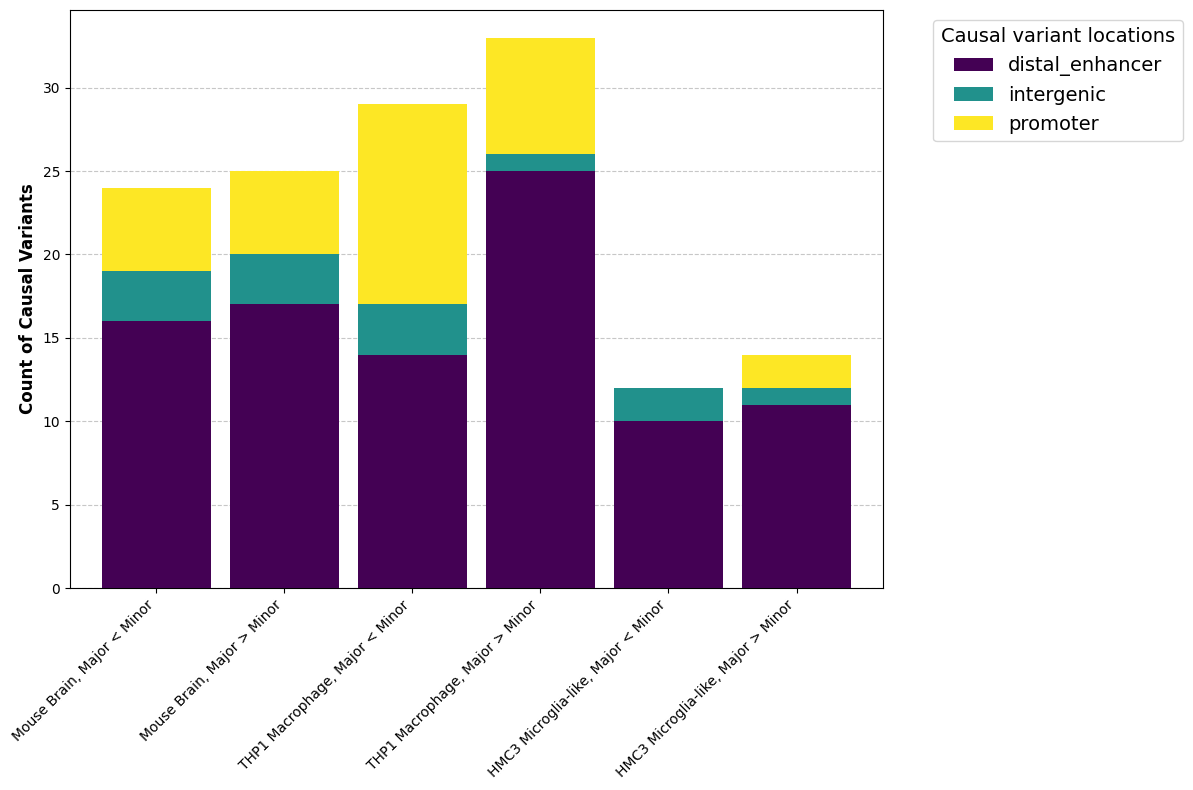

In [5]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# Load and Process CSV Files
# -------------------------------

df_index = pd.read_csv(
    "indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv", 
    index_col=0
)

folder_path = "/media/zihengc/T7/mpra3_lib_analysis/causal_alleles"
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

all_counts = []

for file_path in csv_files:
    df = pd.read_csv(file_path, on_bad_lines='skip')  # Handle errors gracefully
    
    # Ensure 'hierarchical_label' column exists
    if "hierarchical_label" not in df.columns:
        print(f"Skipping {file_path}: 'hierarchical_label' column missing.")
        continue
    
    # Count occurrences of each label
    freq_series = df["hierarchical_label"].value_counts()
    
    # Convert to DataFrame
    file_name = os.path.splitext(os.path.basename(file_path))[0]  # Extract filename
    freq_df = freq_series.to_frame(name=file_name)
    
    # Collect data
    all_counts.append(freq_df)

# Combine all frequency tables
if not all_counts:
    raise ValueError("No valid CSV files found or no 'hierarchical_label' column present.")

combined_df = pd.concat(all_counts, axis=1).fillna(0)

# Transpose so that rows = sample_name, columns = hierarchical_label
combined_df_T = combined_df.T.iloc[0:6,]

# Define selected samples
selected_samples = [
    '20241029_BrainR1R2merged20240404_Major_greater_Minor_case135_withMAD',
    '20241029_BrainR1R2merged20240404_Major_less_Minor_case246_withMAD',
    '20241029_THP1Macrophage_Major_greater_Minor_case135_withMAD',
    '20241029_THP1Macrophage_Major_less_Minor_case246_withMAD',
    '20241029_HMC3_Major_greater_Minor_case135_withMAD',
    '20241029_HMC3_Major_less_Minor_case246_withMAD'
]

# Subset the DataFrame
combined_df_T = combined_df_T.loc[selected_samples]

# Rename index for better readability
index_mapping = {
    '20241029_BrainR1R2merged20240404_Major_greater_Minor_case135_withMAD': 'Mouse Brain, Major > Minor',
    '20241029_BrainR1R2merged20240404_Major_less_Minor_case246_withMAD': 'Mouse Brain, Major < Minor',
    '20241029_THP1Macrophage_Major_greater_Minor_case135_withMAD': 'THP1 Macrophage, Major > Minor',
    '20241029_THP1Macrophage_Major_less_Minor_case246_withMAD': 'THP1 Macrophage, Major < Minor',
    '20241029_HMC3_Major_greater_Minor_case135_withMAD': 'HMC3 Microglia-like, Major > Minor',
    '20241029_HMC3_Major_less_Minor_case246_withMAD': 'HMC3 Microglia-like, Major < Minor'
}
combined_df_T.index = [index_mapping[sample] for sample in combined_df_T.index]

# -------------------------------
# Group Samples (Ensure Adjacent Bars)
# -------------------------------
def group_index(sample_name):
    if "HMC3" in sample_name:
        return "HMC3 Microglia-like"
    elif "Brain" in sample_name:
        return "Mouse Brain"
    elif "THP1" in sample_name:
        return "THP1 Macrophage"
    else:
        return "Other"

# Create 'group' column
combined_df_T["group"] = combined_df_T.index.to_series().apply(group_index)
combined_df_T["sample"] = combined_df_T.index  # Preserve original sample name

# Ensure the group order is respected
group_order = ["Mouse Brain", "THP1 Macrophage", "HMC3 Microglia-like"]
combined_df_T["group"] = pd.Categorical(combined_df_T["group"], categories=group_order, ordered=True)

# Sort based on group and sample name
combined_df_T = combined_df_T.sort_values(by=["group", "sample"], ascending=[True, True])

# Drop extra columns for plotting
plot_df = combined_df_T.drop(columns=["group", "sample"])

# Force the correct order in x-axis
plot_df.index = pd.CategoricalIndex(plot_df.index, categories=plot_df.index, ordered=True)

# -------------------------------
# Ensure Label Order is Correct
# -------------------------------
label_order = list(plot_df.columns)
if "intergenic" in label_order and "promoter" in label_order:
    intergenic_idx, promoter_idx = label_order.index("intergenic"), label_order.index("promoter")
    label_order[intergenic_idx], label_order[promoter_idx] = label_order[promoter_idx], label_order[intergenic_idx]

# Reorder DataFrame columns explicitly based on the updated label order
plot_df = plot_df[label_order]

# -------------------------------
# Plot a Stacked Bar Chart With Updated Label Order
# -------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

# Create a stacked bar plot with reordered labels
plot_df.plot(
    kind="bar",
    stacked=True,
    colormap="viridis",
    ax=ax,
    width=0.85,  # Adjust width to reduce gaps
    zorder=3  # Ensures bars are on top of grid
)

# Hide grid lines behind bars
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)  # Place grid at lower z-order

# Improve readability
ax.set_ylabel("Count of Causal Variants", fontsize=12, fontweight="bold")

# Adjust X-tick labels: Rotate, reduce density
plt.xticks(rotation=45, ha="right", fontsize=10)

# Improve legend placement and formatting
plt.legend(
    title="Causal variant locations",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=14,  # Bigger legend
    title_fontsize=14  # Bigger legend title
)

# Adjust layout
plt.tight_layout()
plt.savefig("stacked_bar_plot_causal_variants_annotation",dpi = 300)
# Show plot
plt.show()


In [ ]:
df_case246 = pd.concat([df_Brain,df_HMC3,df_THP1])

In [1]:
import os
import pandas as pd
import numpy as np

# Define the folder containing your files
input_folder = "/media/zihengc/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/20240813_allele_only"

# Initialize DataFrames to store the results
combined_data = pd.DataFrame()
df_sign = pd.DataFrame()

# Iterate through all files in the folder
for file in os.listdir(input_folder):
    if file.endswith(".csv"):  # Adjust file extension if necessary
        file_path = os.path.join(input_folder, file)
        
        # Extract the column name from the filename
        file_parts = file.split("_")
        if len(file_parts) >= 3:  # Ensure the filename has enough parts
            column_name = file_parts[-3] + file_parts[-2]
        else:
            print(f"Filename {file} does not match expected format, skipping.")
            continue  # Skip files that don't match the pattern
        
        # Read the file and process it
        df = pd.read_csv(file_path, index_col=0)
        if "logFC" in df.columns and "fdr" in df.columns:
            # Add the 'fdr' column to combined_data
            combined_data[column_name] = df["fdr"]
            # Add the sign of 'logFC' to df_sign
            df_sign[column_name] = np.sign(df["logFC"])
        else:
            print(f"Required columns not found in {file}, skipping.")

# Ensure specified columns exist before selection
required_columns = [
    'comparativeBrainR1R2merged20240404',
    'comparativeTHP1Macrophage',
    'comparativeHMC3'
]
available_columns = [col for col in required_columns if col in combined_data.columns]

# Select only the required columns, if they exist
if available_columns:
    combined_data = combined_data[available_columns]
    df_sign = df_sign[available_columns]
else:
    print("None of the required columns are available in the combined data.")

# Display the results (or save as needed)
print("Combined Data (fdr):")
print(combined_data)
print("\nSign Data (logFC):")
print(df_sign)

# Save the results to CSV if needed
# combined_data.to_csv("combined_logFC.csv", index=False)
# df_sign.to_csv("combined_logFC_sign.csv", index=False)


Combined Data (fdr):
                                                    comparativeBrainR1R2merged20240404  \
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:429...                            0.002381   
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:895...                            0.007225   
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255...                            0.676515   
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:4151...                            0.270039   
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720...                            0.867268   
...                                                                                ...   
alt:rs9478143:PEAKCENTER:chr6:150862035:A:G:150...                            0.095033   
alt:rs953471:PEAKCENTER:chr9:124221903:G:A:1242...                            0.088055   
alt:rs965034941:SNPCENTER:chr19:1999195:CCA:C:1...                            0.039480   
alt:rs983392:PEAKCENTER:chr11:59923508:A:G:5992...                            0

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
index = df_case135.index.tolist()+df_case246.index.tolist()
df = -np.log10(combined_data)*df_sign

sns.clustermap(df.loc[index].T,cmap='coolwarm',figsize=(30,10),center = 0,vmax=2,vmin=-2)

NameError: name 'df_case135' is not defined

In [7]:
import os
import pandas as pd
import numpy as np

# Define the folder containing your files
input_folder = "/media/zihengc/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/20240813_allele_only"

# Initialize DataFrames to store the results
combined_data = pd.DataFrame()
df_sign = pd.DataFrame()

# Iterate through all files in the folder
for file in os.listdir(input_folder):
    if file.endswith(".csv"):  # Adjust file extension if necessary
        file_path = os.path.join(input_folder, file)
        
        # Extract the column name from the filename
        file_parts = file.split("_")
        if len(file_parts) >= 3:  # Ensure the filename has enough parts
            column_name = file_parts[-3] + file_parts[-2]
        else:
            print(f"Filename {file} does not match expected format, skipping.")
            continue  # Skip files that don't match the pattern
        
        # Read the file and process it
        df = pd.read_csv(file_path, index_col=0)
        if "logFC" in df.columns and "logFC" in df.columns:
            # Add the 'fdr' column to combined_data
            combined_data[column_name] = df["logFC"]
            # Add the sign of 'logFC' to df_sign
            df_sign[column_name] = np.sign(df["logFC"])
        else:
            print(f"Required columns not found in {file}, skipping.")

# Ensure specified columns exist before selection
required_columns = [
       'BrainR1R2merged20240404Cortex', 'BrainR1R2merged20240404Hippocampus',
       'BrainR1R2merged20240404Striatum','THP1Naive',       'THP1LPSIFNG',  'THP1IFNG',       'THP1IFNB',  'HMC3Naive','HMC3LPSIFNG', 'HMC3IFNG','HMC3IFNB',
]

available_columns = [col for col in required_columns if col in combined_data.columns]

# Select only the required columns, if they exist
if available_columns:
    combined_data = combined_data[available_columns]
    df_sign = df_sign[available_columns]
else:
    print("None of the required columns are available in the combined data.")

# Display the results (or save as needed)
print("Combined Data (fdr):")
print(combined_data)
print("\nSign Data (logFC):")
print(df_sign)

# Save the results to CSV if needed
# combined_data.to_csv("combined_logFC.csv", index=False)
# df_sign.to_csv("combined_logFC_sign.csv", index=False)


Combined Data (fdr):
                                                    BrainR1R2merged20240404Cortex  \
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:429...                       0.302908   
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:895...                      -0.271034   
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255...                       0.229938   
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:4151...                      -0.211632   
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720...                       0.166639   
...                                                                           ...   
alt:rs9478143:PEAKCENTER:chr6:150862035:A:G:150...                      -0.343922   
alt:rs953471:PEAKCENTER:chr9:124221903:G:A:1242...                      -0.313936   
alt:rs965034941:SNPCENTER:chr19:1999195:CCA:C:1...                      -0.217406   
alt:rs983392:PEAKCENTER:chr11:59923508:A:G:5992...                       0.283104   
alt:rs9912783:PEAKCENTER:chr17:61522705:C:T:

<Axes: >

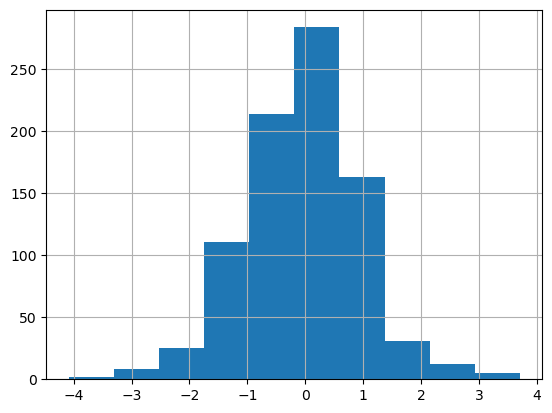

In [84]:
combined_data['BrainR1R2merged20240404Cortex'].hist()

<Axes: >

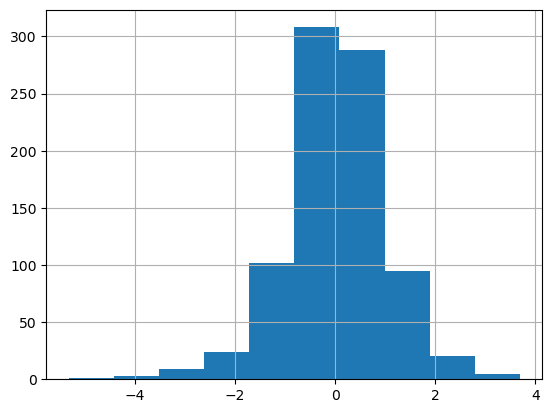

In [85]:
combined_data['THP1Naive'].hist()

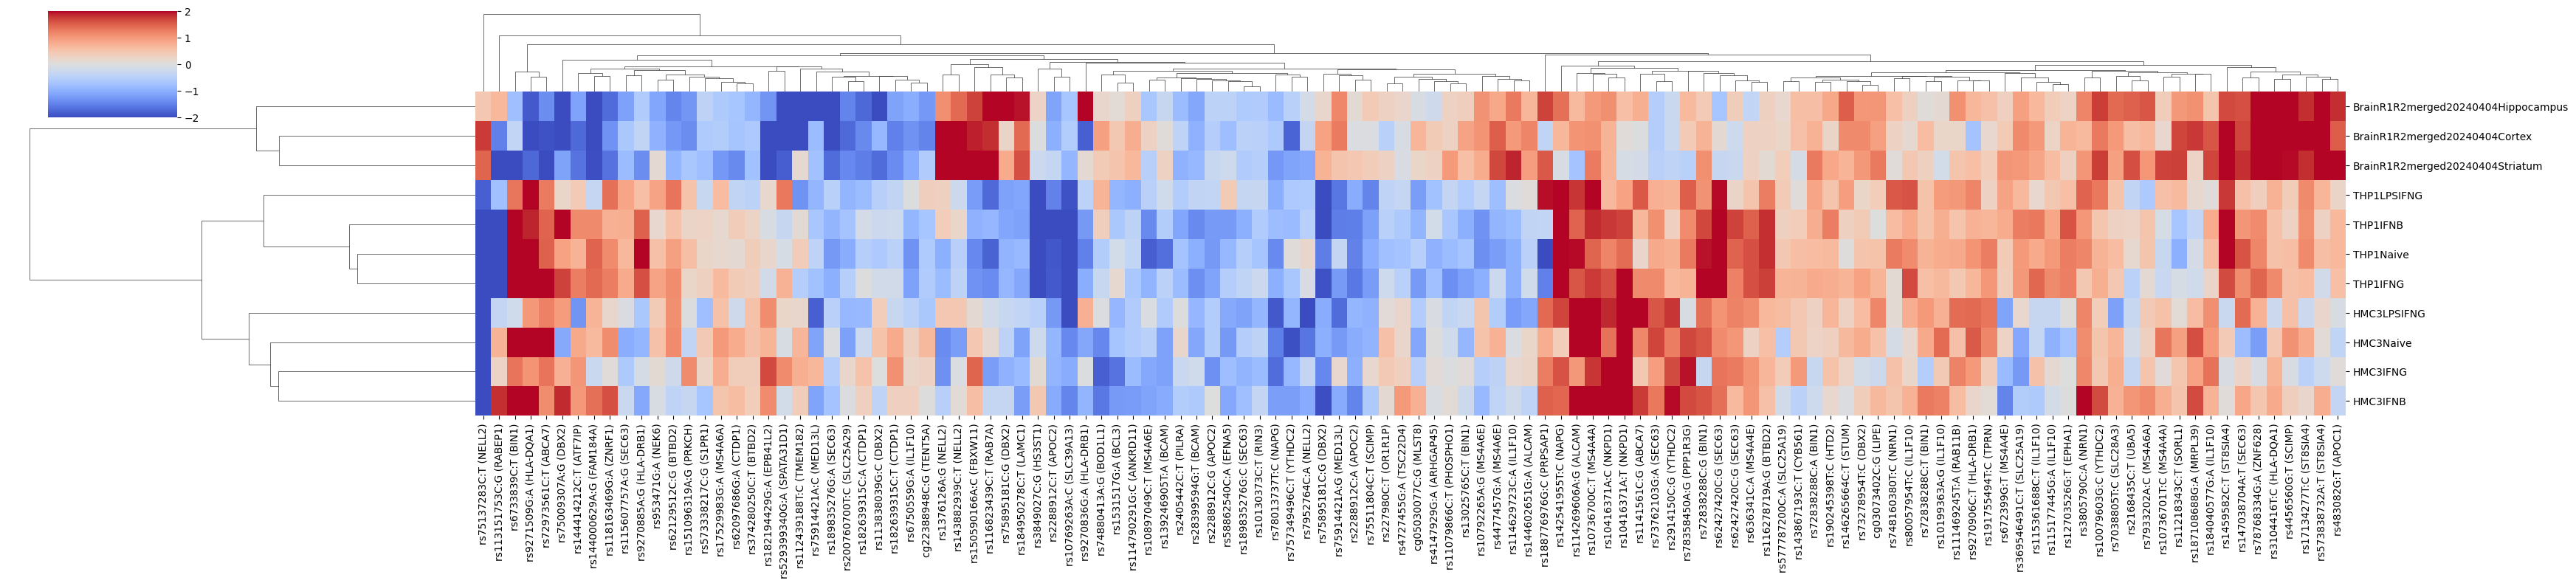

In [15]:
#df.index = df_index['rsid_gene_tss']
import seaborn as sns
import matplotlib.pyplot as plt
index = list(set(df_case135.index.tolist()+df_case246.index.tolist()))
df = combined_data/combined_data.std()
df_visualize=df.loc[index]
df_visualize.index = df_index.loc[df_visualize.index]['rsid_gene_tss'].tolist()
sns.clustermap(df_visualize.T,cmap='coolwarm',figsize=(35,8),center = 0,vmax=2,vmin=-2)
plt.savefig('significant_snps.pdf',format='pdf',dpi=300)

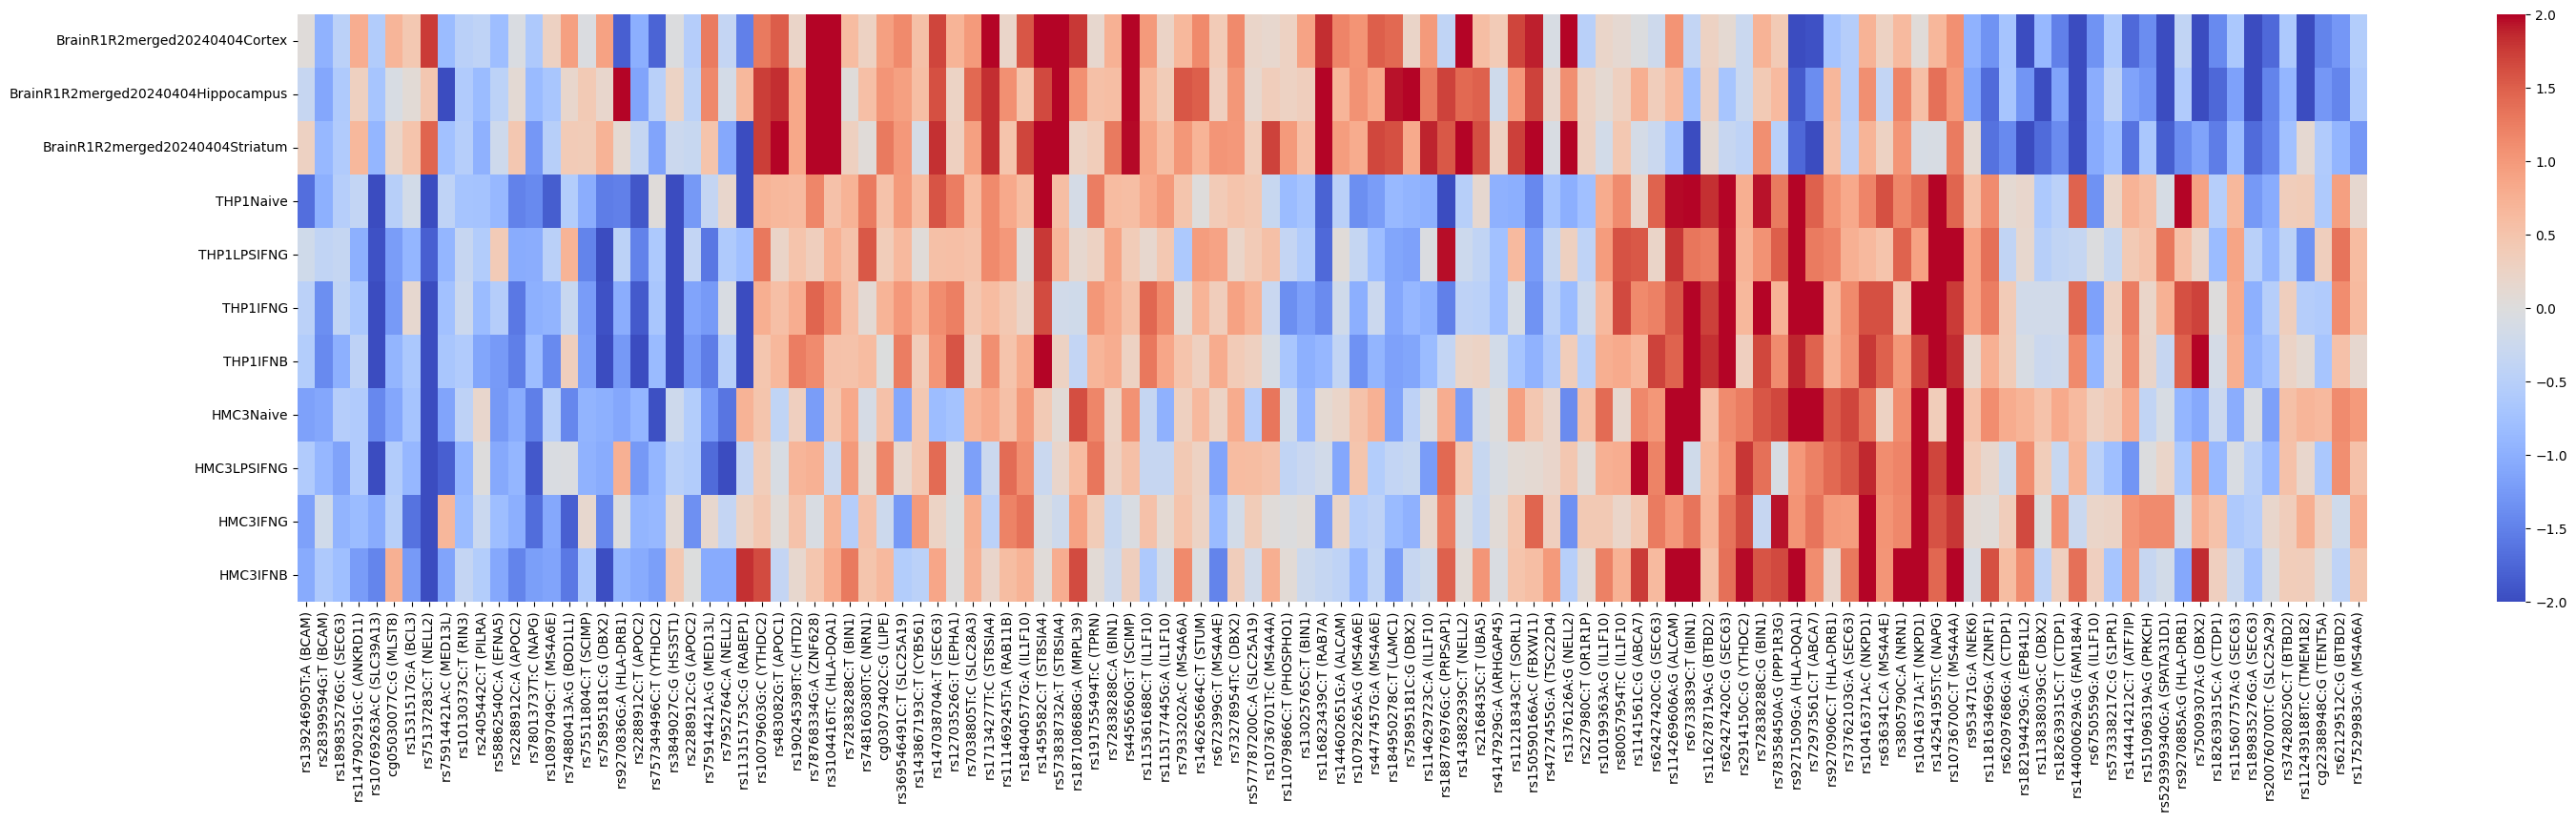

In [16]:
from sklearn.cluster import KMeans

# Normalize the data (already done in your code)
df_scaled = combined_data / combined_data.std()

# Subset to selected index
df_visualize = df_scaled.loc[index]
df_visualize.index = df_index.loc[df_visualize.index]['rsid_gene_tss'].tolist()

# Perform KMeans clustering (you can tune n_clusters)
kmeans = KMeans(n_clusters=5, random_state=0).fit(df_visualize)
df_visualize['cluster'] = kmeans.labels_

# Sort by cluster for heatmap
df_sorted = df_visualize.sort_values('cluster').drop(columns='cluster')

# Plot heatmap (no dendrogram here)
plt.figure(figsize=(35, 8))
sns.heatmap(df_sorted.T, cmap='coolwarm', center=0, vmax=2, vmin=-2)
plt.savefig('kmeans_clustered_snps.pdf', format='pdf', dpi=300)


In [31]:
df_visualize.drop(['HMC3Naive',	'HMC3LPSIFNG',	'HMC3IFNG',	'HMC3IFNB'],axis=1)

,BrainR1R2merged20240404Cortex,BrainR1R2merged20240404Hippocampus,BrainR1R2merged20240404Striatum,THP1Naive,THP1LPSIFNG,THP1IFNG,THP1IFNB,cluster
rs111469245T:A (RAB11B),0.211204,1.084813,0.511715,0.838647,1.007558,0.450008,0.511082,1
rs182639315C:T (CTDP1),-1.504998,-1.153398,-1.398345,-0.459471,-0.387388,-0.187212,-0.227225,4
rs73278954T:C (DBX2),1.154727,1.028019,1.005447,0.513426,0.214779,0.907304,0.401201,1
rs113838039G:C (DBX2),-0.881583,-2.207117,-1.716327,-0.626445,-0.502466,-0.184351,-0.258847,4
rs672399G:T (MS4A4E),0.402082,0.316015,1.036588,0.390861,0.892379,0.354886,0.804102,1
...,...,...,...,...,...,...,...,...
rs144602651G:A (ALCAM),1.197545,0.701282,0.960736,-0.483709,0.058462,-0.197135,-0.388261,2
rs13025765C:T (BIN1),0.893776,0.336163,0.573988,-0.705201,-0.575558,-1.177596,-0.994693,2
rs75895181C:G (DBX2),0.906762,0.186768,0.729159,-1.534184,-2.074795,-1.943150,-2.443389,0
rs58862540C:A (EFNA5),-0.799870,-0.449767,-0.225426,-0.888749,0.391724,-0.544883,-1.239575,0


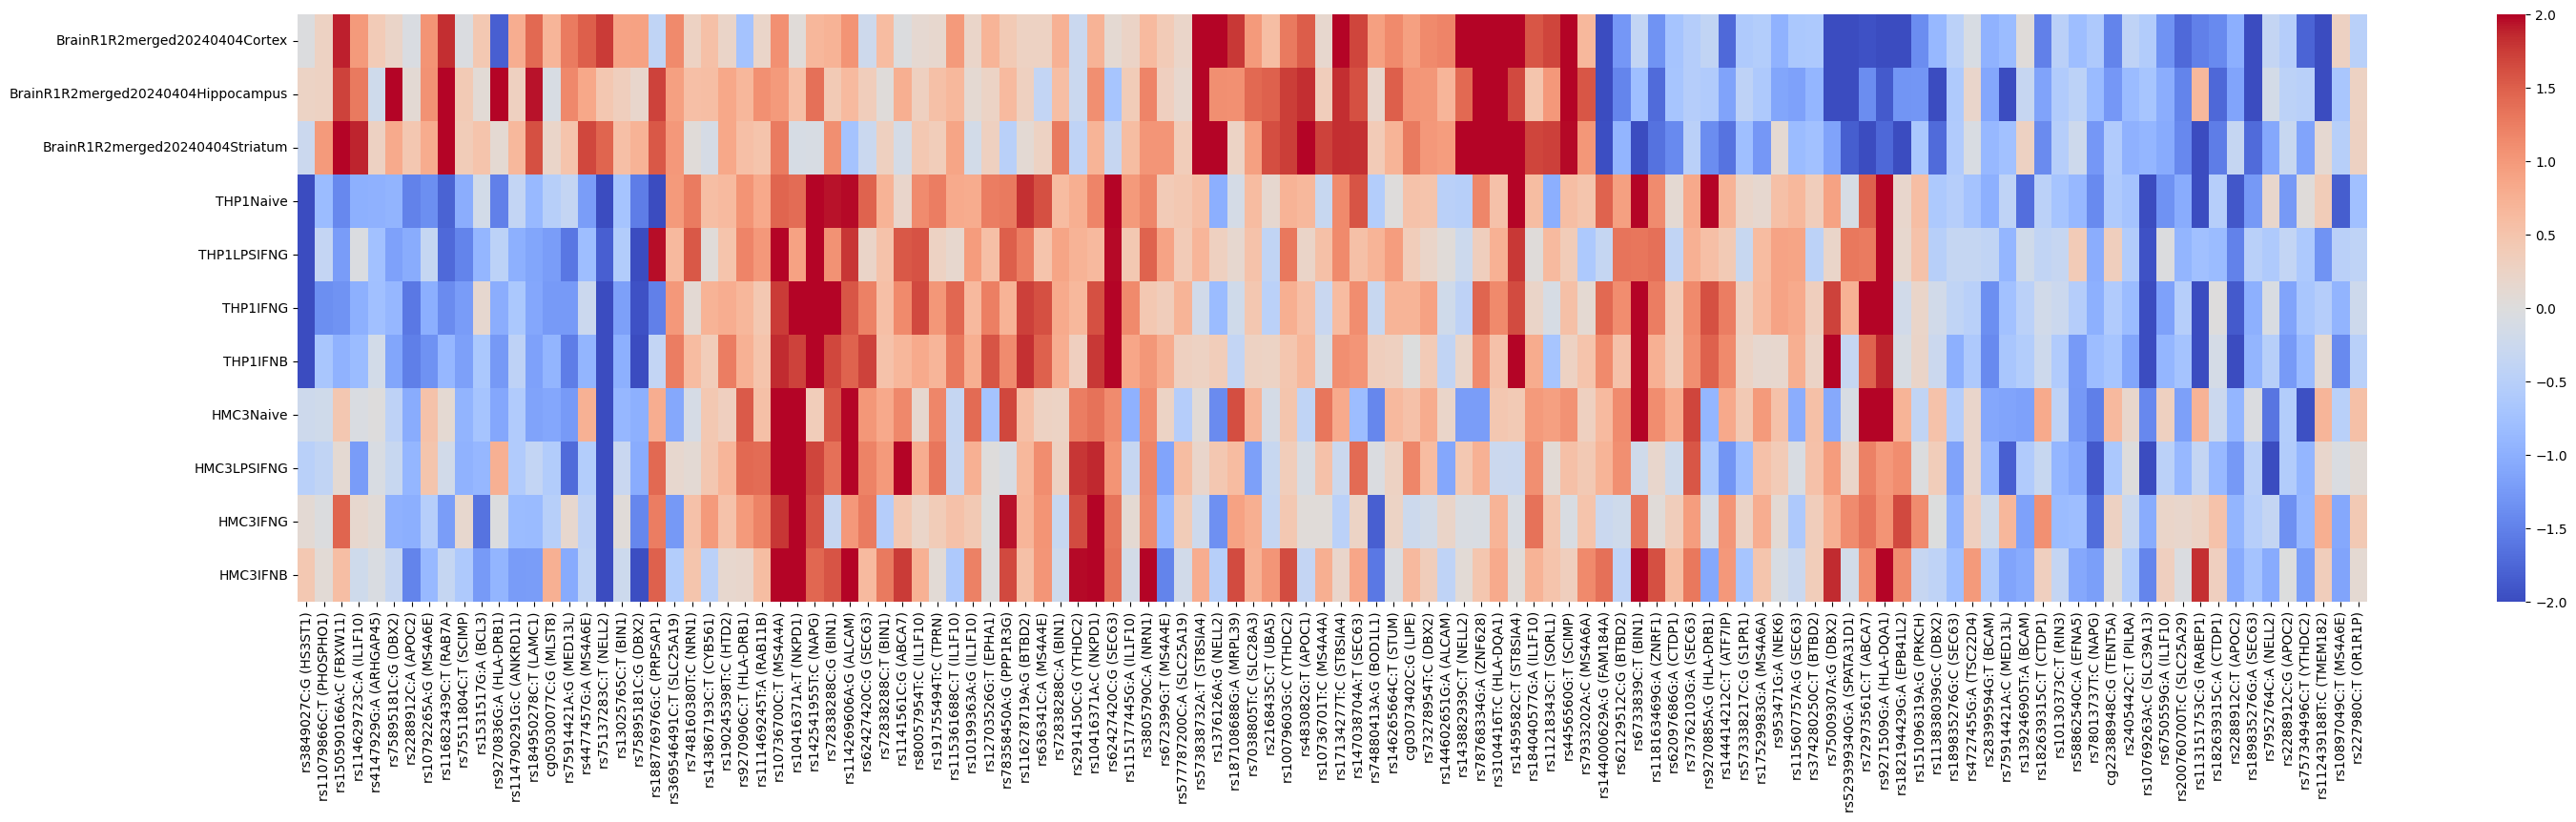

In [46]:
from sklearn.cluster import KMeans

# Normalize the data (already done in your code)
df_scaled = combined_data / combined_data.std()

# Subset to selected index
df_visualize = df_scaled.loc[index]
df_visualize.index = df_index.loc[df_visualize.index]['rsid_gene_tss'].tolist() 
df_visualize_copy=df_visualize.drop(['HMC3Naive',	'HMC3LPSIFNG',	'HMC3IFNG',	'HMC3IFNB'],axis=1).copy()
# Perform KMeans clustering (you can tune n_clusters)
kmeans = KMeans(n_clusters=5, random_state=0).fit(df_visualize_copy)
df_visualize['cluster'] = kmeans.labels_

# Sort by cluster for heatmap
df_sorted = df_visualize.sort_values('cluster').drop(columns='cluster')

# Plot heatmap (no dendrogram here)
plt.figure(figsize=(35, 8))
sns.heatmap(df_sorted.T, cmap='coolwarm', center=0, vmax=2, vmin=-2)
plt.savefig('kmeans_clustered_snps.pdf', format='pdf', dpi=300)


In [ ]:
df_index['rsid_gene_tss'] = df_index["rsid"]+df_index['Major']+":"+df_index['Minor']+" ("+df_index["closest_protein_coding_gene_TSS"]+")"
df_index.to_csv(    "indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv")


In [145]:
df_index2 = pd.read_csv("indexing/20241021_SNPs_GWAS_match_pvalue_uniqueSNPs.csv")
df_index2 = pd.merge(df_index2,df_index[['closest_protein_coding_gene_TSS','rsID']],left_on='rsID',right_on='rsID',how='inner').drop_duplicates()
df_index2.to_csv("indexing/20250121_SNPs_GWAS_match_pvalue_uniqueSNPs.csv")